# Notebook for MTSAD comparison 

In [ ]:
import os, sys, torch, umap, copy, math, json, time, re, random
from contextlib import contextmanager
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import recall_score, average_precision_score, f1_score, roc_auc_score, brier_score_loss, precision_recall_curve
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
from pathlib import Path
import warnings
from collections import defaultdict

BASE_PATH = Path(r"C:\Users\Lidia\GitHub\Itefi_Argus\src")
USAD_REPO = Path(r"C:\Users\Lidia\AD_benchmarks\usad")
OMNIANOMALY_REPO = Path(r"C:\Users\Lidia\AD_benchmarks\OmniAnomaly")
GDN_REPO = Path(r"C:\Users\Lidia\AD_benchmarks\GDN")
MTADGAT_REPO = Path(r"C:\Users\Lidia\AD_benchmarks\mtad-gat-pytorch")
ANOMALYTRANSFORMER_REPO = Path(r"C:\Users\Lidia\AD_benchmarks\Anomaly-Transformer")
TIMESNET_REPO = Path(r"C:\Users\Lidia\AD_benchmarks\Time-Series-Library")
LSTMVAE_REPO = Path(r"C:\Users\Lidia\AD_benchmarks\lstm-vae-torch")

os.chdir(BASE_PATH)
print("Now in:", os.getcwd())

sys.path.insert(0, str(BASE_PATH))

from models import archs as models
from data import pilots_preprocessing as pp

C:\Users\Lidia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Now in: C:\Users\Lidia\GitHub\Itefi_Argus\src


# Helpers

The following cell supresses other modules called output prints and warnings for a clearner notebook

In [2]:
@contextmanager
def suppress_all():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        
        sys.stdout = devnull
        sys.stderr = devnull
        
        # Suppress warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            try:
                yield
            finally:
                sys.stdout = old_stdout
                sys.stderr = old_stderr

In [ ]:

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


Threshold to define which instances are in the end anomalies (above threhsold) and which arent (bellow threhosld)

In [ ]:
def compute_threshold(scores_train): 
    # --- basic stats --- 
    mean_val = np.mean(scores_train) 
    median_val = np.median(scores_train) 
    std_val = np.std(scores_train) 
    # --- MAD --- 
    abs_dev = np.abs(scores_train - median_val) 
    mad_val = np.median(abs_dev) 
    # scaled MAD (std-equivalent) 
    mad_scaled = 1.4826 * mad_val
    # --- thresholds for comparison --- 
    thr_std = mean_val + 3 * std_val 
    thr_mad = median_val + 3 * mad_scaled 

    threshold=thr_mad
    print(f"Final threshold: {threshold:.4f} \n")
    return threshold

Metrics and PU-Metrics for SOTA models

In [6]:
def compute_metrics(true_labels, scores, preds=None, threshold=None):

    true_labels = np.asarray(true_labels)
    scores = np.asarray(scores[:len(true_labels)])

    total_positives = np.sum(true_labels)
    idx_sorted = np.argsort(-scores)


    # PRECISION@K & RECALL@K
    if total_positives > 0:
        #K = int(np.sum(true_labels))
        K=int(len(true_labels)*0.1) #before 20
        print("Used K: ", K)
        top_k_idx = idx_sorted[:K]

        tp_at_k = np.sum(true_labels[top_k_idx])

        precision_at_k = tp_at_k / K
        recall_at_k    = tp_at_k / total_positives
    else:
        precision_at_k = 0.0
        recall_at_k = 0.0

    # PR-AUC
    ap = average_precision_score(true_labels, scores)
    return {
        "Precision@K": precision_at_k.round(6),
        "Recall@K": recall_at_k.round(6),
        "AP": ap,
    }

In [5]:
def normalize_scores(scores):
    """Normaliza scores a [0,1] preservando ranking."""
    scaler = MinMaxScaler()
    return scaler.fit_transform(scores.reshape(-1, 1)).ravel()

def select_reliable_negatives(P_scores, U_scores, pi=0.1, theta_quantile=0.1):
    """Igual que antes, pero con scores normalizados."""
    # Normaliza primero
    P_norm = normalize_scores(P_scores)
    U_norm = normalize_scores(U_scores)
    
    n_spy = int(len(P_norm) * pi)
    spy_scores = np.random.choice(P_norm, n_spy, replace=False)
    theta = np.quantile(spy_scores, theta_quantile)
    
    RN_mask = U_norm < theta
    RN_scores = U_norm[RN_mask]
    
    return RN_scores, theta

def pu_auc_score(P_scores, U_scores, pi=0.1):
    """PU-AUC con normalización."""
    RN_scores, _ = select_reliable_negatives(P_scores, U_scores, pi)
    
    all_scores = np.concatenate([P_scores, RN_scores])
    labels = np.concatenate([np.ones(len(P_scores)), np.zeros(len(RN_scores))])
    
    # Normaliza solo para métricas probabilísticas
    all_scores_norm = normalize_scores(all_scores)
    
    return roc_auc_score(labels, all_scores_norm)

def pu_f1_score(P_scores, U_scores, threshold='auto', pi=0.1):
    """PU-F1 con normalización."""
    RN_scores, theta = select_reliable_negatives(P_scores, U_scores, pi)
    
    all_scores = np.concatenate([P_scores, RN_scores])
    all_scores_norm = normalize_scores(all_scores)
    all_true = np.concatenate([np.ones(len(P_scores)), np.zeros(len(RN_scores))])
    
    if threshold == 'auto':
        precisions, recalls, thresholds = precision_recall_curve(all_true, all_scores_norm)
        f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
        best_idx = np.argmax(f1_scores)
        best_threshold = thresholds[best_idx]
        all_pred = (all_scores_norm >= best_threshold).astype(int)
    else:
        all_pred = (all_scores_norm >= threshold).astype(int)
    
    return f1_score(all_true, all_pred)

def pu_brier_score(P_scores, U_scores, pi=0.1):
    """PU-Brier AHORA FUNCIONA con normalización."""
    RN_scores, _ = select_reliable_negatives(P_scores, U_scores, pi)
    
    all_scores = np.concatenate([P_scores, RN_scores])
    all_scores_norm = normalize_scores(all_scores)  # ← ESTO ARREGLA EL ERROR
    all_true = np.concatenate([np.ones(len(P_scores)), np.zeros(len(RN_scores))])
    
    return brier_score_loss(all_true, all_scores_norm)

def compute_pu_metrics(anomaly_scores, non_anomaly_scores): 

    if len(anomaly_scores) == 0 or len(non_anomaly_scores) == 0:
        return {
            "PU-Brier": 0.0,
            "PU-F1": 0.0,
            "PU-AUC": 0.0
        }

    brier_score = pu_brier_score(anomaly_scores, non_anomaly_scores)
    f1 = pu_f1_score(anomaly_scores, non_anomaly_scores)
    auc = pu_auc_score(anomaly_scores, non_anomaly_scores)
    
    return { "PU-Brier": brier_score, "PU-F1": f1, "PU-AUC": auc}

For several implementations 

In [8]:
def get_scores(model,loader,block_attn,block_tcn, revin, beta, rec_refs, fc_refs, alpha_ema=0.5, return_outputs=None):
    
    model.eval()

    scores = []
    y_pred1_list = []
    y_pred2_list = []
    y_true_list = []

    device = "cpu"

    with torch.no_grad():
        for x_p, y_rec, y_fc, alive, label in loader:
            x = x_p.to(device)
            y_rec = y_rec.to(device)
            y_fc = y_fc.to(device)
            alive = alive[:, :-1, :].to(device)

            y_pred1, y_pred2 = model(x, block_attn=block_attn, block_tcn=block_tcn)

            # ---------------- OUTPUT COLLECTION ----------------
            if return_outputs in ["preds", "labels"]:
                y_pred1_list.append(y_pred1[:, -1, :].cpu().numpy())
                y_pred2_list.append(y_pred2.cpu().numpy())

            if return_outputs == "labels":
                y_true_list.append(label.cpu().numpy())

            # ---------------- ERRORS ----------------
            rec_err = torch.abs(y_pred1 - y_rec)
            fc_err = torch.abs(y_pred2 - y_fc)

            rec_err_np = rec_err.cpu().numpy()   # [B,T,F]
            fc_err_np  = fc_err.cpu().numpy()    # [B,F]
            # Normalize along dim 2 (features)
            rec_n_np = rec_err_np / rec_refs.reshape(1, 1, -1)
            fc_n_np  = fc_err_np  / fc_refs.reshape(1, -1)

            # -------------------SCORES---------------------
            ema_feat = np.zeros_like(rec_n_np)
            ema_feat[:, 0, :] = rec_n_np[:, 0, :]
            for t in range(1, rec_n_np.shape[1]):
                ema_feat[:, t, :] = (alpha_ema * ema_feat[:, t - 1, :]+ (1 - alpha_ema) * rec_n_np[:, t, :])
            rec_feat_score = ema_feat[:, -1, :]
            fc_feat_score = fc_n_np

            # ---------------- FINAL SCORE ----------------
            rec_score = rec_feat_score.mean(-1)
            fc_score = fc_feat_score.mean(-1)

            score = beta * rec_score + (1 - beta) * fc_score
            scores.append(score)

    scores = np.concatenate(scores, axis=0)

    # ---------------- RETURN LOGIC ----------------
    if return_outputs is None:
        return scores

    if return_outputs == "preds":
        y_pred1_out = np.concatenate(y_pred1_list, axis=0)
        y_pred2_out = np.concatenate(y_pred2_list, axis=0)
        return scores, y_pred1_out, y_pred2_out

    if return_outputs == "labels":
        y_true_out = np.concatenate(y_true_list, axis=0)
        return scores, y_true_out

    raise ValueError("return_outputs must be None, 'preds', or 'labels'")


# R1. Comparison with SOTA

### SOTA models wrappers

The following cell clears modules that are read otherwise by default because we have added out base path as first priority. When we call e.g. usad we need it to use its own utils not the ones by default (ours)

In [10]:
@contextmanager
def use_repo(path):
    old_path = list(sys.path)

    #  REMOVE conflicting cached modules
    modules_to_clear = ["utils", "models", "data"]  # add more if needed
    backup = {m: sys.modules[m] for m in modules_to_clear if m in sys.modules}

    for m in modules_to_clear:
        if m in sys.modules:
            del sys.modules[m]

    # insert repo at highest priority
    sys.path.insert(0, str(path))

    try:
        yield
    finally:
        # restore sys.path
        sys.path = old_path

        # restore modules
        sys.modules.update(backup)

In [12]:
def run_iforest(X_train, X_test, revin=False):

    iso = IsolationForest(random_state=42, n_jobs=-1,
                          max_samples=256,       # subsample — acts as regularization
                          max_features=0.7)      # feature subsampling)
    iso.fit(X_train)

    scores = -iso.decision_function(X_test)
    preds = iso.predict(X_test) == -1

    return scores, preds

In [ ]:
def run_usad(X_train, X_val, X_test, train_loader, val_loader, test_loader):

    TF = X_train.shape[1]


    with use_repo(USAD_REPO):
        if "utils" in sys.modules:
            del sys.modules["utils"]

        import utils
        from usad import UsadModel, training, testing

        device = utils.get_default_device()
        to_device = utils.to_device

        w_size = TF
        z_size = int(TF * 32 / (TF // 72))
        print(z_size)

        model = UsadModel(w_size=w_size, z_size=z_size)
        model = to_device(model, device)

        training(epochs=100, model=model, train_loader=train_loader, val_loader=val_loader)

        train_scores = torch.cat(testing(model, train_loader)).cpu().numpy()
        val_scores   = torch.cat(testing(model, val_loader)).cpu().numpy()
        test_scores  = torch.cat(testing(model, test_loader)).cpu().numpy()

        return train_scores, val_scores, test_scores


In [ ]:
class GDNUnsupervisedDataset(torch.utils.data.Dataset):
    def __init__(self, X, edge_index):
        self.X = torch.tensor(X, dtype=torch.float32)  # [B, N, T]
        self.edge_index = edge_index

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]              # [N, T]
        y = x[:, -1]                 # [N]
        
        attack_label = torch.tensor(0.0)

        return x, y, attack_label, self.edge_index

def run_gdn(X_train_seq, X_val_seq, X_test_seq):

    with use_repo(GDN_REPO):
        if "utils" in sys.modules:
            del sys.modules["utils"]
        if "models" in sys.modules:
            del sys.modules["models"]

        import torch_geometric
        torch_geometric.typing.WITH_TORCH_SCATTER = False
        torch_geometric.typing.WITH_SOFTMAX = False

        from models.GDN import GDN
        from train import train as gdn_train
        from test import test as gdn_test
        from util.env import set_device

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        set_device(device)

        T = X_train_seq.shape[1]
        F = X_train_seq.shape[2]

        edge_index = torch.tensor(
            [[i, j] for i in range(F) for j in range(F) if i != j],
            dtype=torch.long
        ).t().contiguous()

        # GDN expects [B, F, T]
        X_train_seq = X_train_seq.transpose(0, 2, 1)
        X_val_seq   = X_val_seq.transpose(0, 2, 1)
        X_test_seq  = X_test_seq.transpose(0, 2, 1)

        train_dataset = GDNUnsupervisedDataset(X_train_seq, edge_index)
        val_dataset   = GDNUnsupervisedDataset(X_val_seq, edge_index)
        test_dataset  = GDNUnsupervisedDataset(X_test_seq, edge_index)

        train_loader = DataLoader(train_dataset, batch_size=256, shuffle=False)
        val_loader   = DataLoader(val_dataset, batch_size=256, shuffle=False)
        test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False)

        train_config = {
            "batch": 256,
            "epoch": 100,
            "slide_win": T,
            "slide_stride": 1,
            "dim": 32,
            "out_layer_num": 1,
            "out_layer_inter_dim": 64,
            "seed": 42,
            "decay": 0,
            "val_ratio": 0.1,
            "topk": 5,
        }

        model = GDN(
            edge_index_sets=[edge_index],
            node_num=F,
            dim=32,
            input_dim=T,
            out_layer_num=1,
            out_layer_inter_dim=64,
            topk=5
        ).to(device)

        gdn_train(
            model,
            save_path="gdn_model.pt",
            config=train_config,
            train_dataloader=train_loader,
            val_dataloader=val_loader,
            feature_map=None,
            test_dataloader=test_loader,
            test_dataset=None,
            train_dataset=None,
            dataset_name="custom"
        )

        def eval_gdn(model, loader):
            model.eval()
            with torch.no_grad():
                _, results = gdn_test(model, loader)
                scores = np.array(results[0])
                return np.max(scores, axis=1)

        return (
            eval_gdn(model, train_loader),
            eval_gdn(model, val_loader),
            eval_gdn(model, test_loader)
        )


In [ ]:
def run_mtad_gat(X_train, X_val, X_test, train_loader, val_loader, test_loader):

    with use_repo(MTADGAT_REPO):
        if "utils" in sys.modules:
            del sys.modules["utils"]

        from mtad_gat import MTAD_GAT
        from training import Trainer

        n_features = X_train.shape[2]

        model = MTAD_GAT(
            n_features=n_features,
            window_size=72,
            out_dim=n_features
        )

        optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

        trainer = Trainer(
            model=model,
            optimizer=optimizer,
            window_size=72,
            n_features=n_features,
            n_epochs=100,
            dload="mtad_checkpoints"
        )

        trainer.fit(train_loader=train_loader, val_loader=val_loader)

        def eval_mtad(model, loader, gamma=0.5):
            model.eval()
            scores = []
            with torch.no_grad():
                for batch in loader:
                    x = batch[0].to(next(model.parameters()).device)
                    forecast, recon = model(x)          # forecast: [B, F], recon: [B, T, F]
                    target = x[:, -1, :]                 # single-step forecast target, [B, F]
                    print(forecast.dim, target.dim)
                    rec_err = torch.mean((recon - x) ** 2, dim=(1, 2))     # [B]
                    fc_err  = torch.mean((forecast - target) ** 2, dim=1)  # [B]

                    score = gamma * fc_err + (1 - gamma) * rec_err
                    scores.append(score.cpu())
            return torch.cat(scores).numpy()

        return (
            eval_mtad(model, train_loader),
            eval_mtad(model, val_loader),
            eval_mtad(model, test_loader)
        )


In [ ]:
def run_anomtr(X_train, X_val, X_test, train_loader, val_loader, test_loader, data_path):

    with use_repo(ANOMALYTRANSFORMER_REPO):
        if "utils" in sys.modules:
            del sys.modules["utils"]

        from solver import Solver, my_kl_loss

        class Args:
            def __init__(self):
                self.batch_size = 256
                self.win_size = X_train.shape[1]
                self.lr = 1e-4
                self.num_epochs =100
                self.k = 3
                self.input_c = X_train.shape[-1]
                self.output_c = X_train.shape[-1]
                self.dataset = "custom"
                self.data_path = data_path
                self.model_save_path = "checkpoints"
                self.pretrained_model = None
                self.anormly_ratio = 1.0
                self.mode = "train"
                self.device = "cuda" if torch.cuda.is_available() else "cpu"

        args = Args()

        solver = Solver(vars(args))
        solver.train_loader = train_loader
        solver.vali_loader = val_loader
        solver.test_loader = test_loader

        solver.train()
        
        def compute_anomtr_energy(solver, loader, temperature=50, my_kl_loss=my_kl_loss):
            """
            Mirrors the energy computation in Solver.test() steps (1)/(2)/(3);
            keep this in sync with solver.py's my_kl_loss / model output signature
            if that repo is ever updated.
            """

            model = solver.model
            model.eval()
            criterion = torch.nn.MSELoss(reduction='none')
            win_size = solver.win_size

            energies = []
            with torch.no_grad():
                for input_data, _ in loader:
                    x = input_data.float().to(solver.device)
                    output, series, prior, _ = model(x)

                    loss = torch.mean(criterion(x, output), dim=-1)  # [B, W]

                    series_loss = 0.0
                    prior_loss = 0.0
                    for u in range(len(prior)):
                        normed_prior = prior[u] / torch.sum(prior[u], dim=-1, keepdim=True).repeat(1, 1, 1, win_size)
                        series_loss += my_kl_loss(series[u], normed_prior.detach()) * temperature
                        prior_loss  += my_kl_loss(normed_prior, series[u].detach()) * temperature

                    metric = torch.softmax((-series_loss - prior_loss), dim=-1)
                    cri = (metric * loss).detach().cpu().numpy()  # [B, W]
                    energies.append(cri)

            return np.concatenate(energies, axis=0).reshape(-1)
        
        train_scores = compute_anomtr_energy(solver, train_loader, my_kl_loss=my_kl_loss)
        val_scores   = compute_anomtr_energy(solver, val_loader, my_kl_loss=my_kl_loss)
        test_scores  = compute_anomtr_energy(solver, test_loader, my_kl_loss=my_kl_loss)

        return (
            train_scores,
            val_scores,
            test_scores
        )


In [ ]:
class TimesNetDataset(torch.utils.data.Dataset):

    def __init__(self, X):
        """
        X shape:
        [B, T, F]
        """

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        x = self.X[idx]

        # reconstruction target
        return x, x

def run_timesnet(X_train_seq, X_val_seq, X_test_seq):

    with use_repo(TIMESNET_REPO):

        if "utils" in sys.modules:
            del sys.modules["utils"]

        from models.TimesNet import Model as TimesNet

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        B, T, F = X_train_seq.shape

        train_dataset = TimesNetDataset(X_train_seq)
        val_dataset   = TimesNetDataset(X_val_seq)
        test_dataset  = TimesNetDataset(X_test_seq)

        train_loader = DataLoader(train_dataset, batch_size=256, shuffle=False, drop_last=False)
        val_loader   = DataLoader(val_dataset, batch_size=256, shuffle=False)
        test_loader  = DataLoader(test_dataset, batch_size=256, shuffle=False)

        class Config:
            task_name = "anomaly_detection"
            seq_len = T
            label_len = 0
            pred_len = 0
            enc_in = F
            dec_in = F
            c_out = F
            d_model = 32
            d_ff = 32
            e_layers = 1
            top_k = 3
            num_kernels = 3
            embed = "timeF"
            freq = "h"
            dropout = 0.3
            factor = 1
            n_heads = 4
            activation = "gelu"
            moving_avg = 25
            distil = True
            use_gpu = torch.cuda.is_available()

        config = Config()
        model = TimesNet(config).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        criterion = nn.MSELoss(reduction="none")

        for epoch in range(100):
            model.train()
            for batch_x, _ in train_loader:
                batch_x = batch_x.to(device)
                optimizer.zero_grad()
                outputs = model(batch_x, None, None, None)
                loss = criterion(outputs, batch_x).mean()
                loss.backward()
                optimizer.step()

        def compute_scores(loader):
            model.eval()
            all_scores = []
            with torch.no_grad():
                for batch_x, _ in loader:
                    batch_x = batch_x.to(device)
                    outputs = model(batch_x, None, None, None)
                    err = ((outputs - batch_x) ** 2).mean(dim=(1, 2))
                    all_scores.append(err.cpu().numpy())
            return np.concatenate(all_scores)

        return (
            compute_scores(train_loader),
            compute_scores(val_loader),
            compute_scores(test_loader)
        )


### Run SOTA models

In [18]:

def store_result(all_results, site, model_name, metrics):
    metrics["site"] = site
    metrics["model"] = model_name
    all_results.append(metrics)
all_results=[]

Helpers for SOTA models 

In [19]:
def extract_from_dataset(ds):
    X, Y, labels, alive = [], [], [], []

    for item in ds:
        x, y, l, a = item
        X.append(x)
        Y.append(y)
        labels.append(l)
        alive.append(a)

    X = torch.stack(X)
    Y = torch.stack(Y)

    return X, Y, np.array(labels), np.array(alive)


def build_btf(X, T):
    """
    Fast sliding window to (B, T, F)
    NO dataset, NO python loops over samples
    """
    X = np.asarray(X)
    
    B = X.shape[0] - T - 1
    
    # vectorized stride trick
    shape = (B, T, X.shape[1])
    strides = (X.strides[0], X.strides[0], X.strides[1])
    
    return np.lib.stride_tricks.as_strided(X, shape=shape, strides=strides)

def window_labels(labels, T):
    labels = np.asarray(labels)
    return np.array([
        int(np.any(labels[i:i+T]))
        for i in range(len(labels) - T + 1)
    ])

def align_labels(labels, scores, window_size=None):
    labels = np.asarray(labels)

    if window_size is not None:
        labels = labels[window_size - 1:]

    return labels[:len(scores)]

def build_fully_connected_graph(n_nodes):
    edges = []
    for i in range(n_nodes):
        for j in range(n_nodes):
            if i != j:
                edges.append([i, j])
    return torch.tensor(edges).t().long()


def window_scores(scores, T):
    scores = np.asarray(scores)
    if len(scores) < T:
        return scores
    return np.lib.stride_tricks.sliding_window_view(scores, T).mean(axis=1)

In [ ]:
pilot_sites = {
    "Schenkenberg": {
        "data_path": "../data/Schenkenberg",
    },
    "Delos": {
        "data_path": "../data/Delos",
    },
    "Baltanas": {
        "data_path": "../data/Baltanas",
    },
    "Lucretili": {
        "data_path": "../data/Lucretili",
    },
    "Ranverso": {
        "data_path": "../data/Ranverso",
    },

}

N_RUNS = 10

all_runs = defaultdict(list)

for site, paths in pilot_sites.items():

    print(f"\n{'='*80}")
    print(f"SITE: {site}")
    print(f"{'='*80}")

    for run in range(N_RUNS):

        seed = 42 + run
        seed_everything(seed)

        print(f"\n---------- RUN {run+1}/{N_RUNS} (seed={seed}) ----------")
        with suppress_all():
            data_path = paths["data_path"]
            base_dataset = pp.TimeSeriesData(data_path, "30min", True)
        
            pre_ds = pp.TSDataset( "both", base_dataset.raw_df_with_alive,base_dataset.raw_df_with_alive.columns.tolist(), 72, 0.1, 0.1, positive=base_dataset.ek_rules[0].max(axis=1), anom_freq=0.05, anom_type="all", anom_sev=1) #, inject_on_init=False)


        train_raw = np.nan_to_num(pre_ds.all_data["train"])
        val_raw   = np.nan_to_num(pre_ds.all_data["val"])
        test_raw  = np.nan_to_num(pre_ds.all_data["test"])
        print(train_raw.shape)
        F_ext = (train_raw.shape[1] + 6) // 2
        F=(train_raw.shape[1] - 6 )// 2
        print(F_ext, F)
        
        T = 72

        X_train = train_raw[:, :F]
        X_val   = val_raw[:, :F]
        X_test  = test_raw[:, :F]
        
        print("\n=====iForest======")
        X_train_w = build_btf(X_train, T).reshape(-1, T *F) # 0 -30 --> idx =0 (as labels)
        X_test_w  = build_btf(X_test, T).reshape(-1, T *F)

        labels = pre_ds.injected_anomalies_labels # this does nto a
        label_idxs = np.where(labels == 1)[0]
        print("\nIndexes where labels == 1:")
        print(label_idxs)

        time_i=time.time()
        scores, preds = run_iforest(X_train_w, X_test_w )#revin=False)
        pred_idxs = np.where(preds)[0]
        print("\nIndexes where preds == -1:")
        print(pred_idxs)
        
        results = compute_metrics(labels, scores, preds)
        pred_idxs = np.where(preds == -1)[0]
        non_pred_idxs = np.where(preds != -1)[0]

        results_pu = compute_pu_metrics(pred_idxs, non_pred_idxs)

        results = {**results, **results_pu}
        print(f"\nIForest ({(time.time()-time_i):.2f} s):", results)
        all_runs[(site, "IForest")].append(results)
        
        # --- REPOS: with val ---
        X_train_s = build_btf(X_train, T)
        X_val_s   = build_btf(X_val, T)
        X_test_s  = build_btf(X_test, T)

        # USAD: window
        print("\n=====USAD======")
        X_train_us = build_btf(X_train, T)
        X_val_us   = build_btf(X_val, T)
        X_test_us  = build_btf(X_test, T)
        X_train_usad = X_train_s.reshape(len(X_train_us), -1)
        X_val_usad   = X_val_s.reshape(len(X_val_us), -1)
        X_test_usad  = X_test_s.reshape(len(X_test_us), -1)

        X_train_t = torch.tensor(X_train_usad, dtype=torch.float32)
        X_val_t   = torch.tensor(X_val_usad, dtype=torch.float32)
        X_test_t  = torch.tensor(X_test_usad, dtype=torch.float32)
        print(X_train_t.shape)
        
        train_loader_usad = DataLoader(TensorDataset(X_train_t), batch_size=256, shuffle=False)
        val_loader_usad   = DataLoader(TensorDataset(X_val_t), batch_size=256, shuffle=False)
        test_loader_usad  = DataLoader(TensorDataset(X_test_t), batch_size=1, shuffle=False)

        time_u = time.time()
        with suppress_all():
            train_scores, val_scores,  test_scores = run_usad(X_train_usad, X_val_usad, X_test_usad, train_loader_usad, val_loader_usad, test_loader_usad)
        print(f"Train scores mean {train_scores.mean():.4f}, std {train_scores.std():.4f}, test scores mean {test_scores.mean():.4f} and std {test_scores.std():.4f}")
        train_val_scores = np.concatenate([train_scores, val_scores])
        thr = compute_threshold(train_val_scores)

        anomaly_idxs = np.where(test_scores > thr)[0]
        print(f"Threshold: {thr:.6f}")
        print("Indexes where scores > threshold:")
        print(anomaly_idxs)
        results = compute_metrics(labels, test_scores, threshold=thr)
        preds = (test_scores > thr).astype(int)
        anom_idxs = np.where(preds == 1)[0]
        normal_idxs = np.where(preds == 0)[0]
        results_pu = compute_pu_metrics(anom_idxs,normal_idxs )
        results = {**results, **results_pu}
        print(f"USAD ({time.time()-time_u:.2f}s):", results)
        all_runs[(site, "USAD")].append(results)

        # MTAD-GAT: temporal (same x, y and loaders also in gdn and anom tr)
        print("\n=====MTAD-GAT=====")
        X_train_seq = torch.tensor(X_train_s[:, :, :], dtype=torch.float32)
        y_train_seq  = torch.tensor(X_train_s[:, -1, :], dtype=torch.float32)
        X_val_seq = torch.tensor(X_val_s[:, :, :], dtype=torch.float32)
        y_val_seq  = torch.tensor(X_val_s[:, -1, :], dtype=torch.float32)
        X_test_seq = torch.tensor(X_test_s[:, :, :], dtype=torch.float32)
        y_test_seq  = torch.tensor(X_test_s[:, -1, :], dtype=torch.float32)
        
        train_loader  = DataLoader(TensorDataset(X_train_seq, y_train_seq), batch_size=256, shuffle=False, drop_last=False)
        val_loader    = DataLoader(TensorDataset(X_val_seq , y_val_seq), batch_size=256, shuffle=False, drop_last=False)
        test_loader  = DataLoader(TensorDataset(X_test_seq , y_test_seq), batch_size=1, shuffle=False)

        time_m = time.time()
        with suppress_all():
            train_scores, val_scores, test_scores =  run_mtad_gat(X_train_seq, X_val_seq, X_test_seq, train_loader , val_loader , test_loader)
        print(f"Train scores mean {train_scores.mean():.4f}, std {train_scores.std():.4f}, test scores mean {test_scores.mean():.4f} and std {test_scores.std():.4f}")
        train_val_scores = np.concatenate([train_scores, val_scores])
        thr = compute_threshold(train_val_scores)
        anomaly_idxs = np.where(test_scores > thr)[0]
        print(f"Threshold: {thr:.6f}")
        print("Indexes where scores > threshold:")
        print(anomaly_idxs)
        results = compute_metrics(labels, test_scores, threshold=thr)
        preds = (test_scores > thr).astype(int)
        anom_idxs = np.where(preds == 1)[0]
        normal_idxs = np.where(preds == 0)[0]
        results_pu = compute_pu_metrics(
            anom_idxs,
            normal_idxs
        )
        results = {**results, **results_pu}
        print(f"MTAD-GAT ({time.time()-time_m:.2f}s):", results)
        all_runs[(site, "IForest")].append(results)
        
        # GDN: temporal
        print("\n=====GDN======")

        time_g = time.time()
        with suppress_all():
            train_scores, val_scores, test_scores  = run_gdn(X_train_s, X_val_s, X_test_s)
        print(f"Train scores mean {train_scores.mean():.4f}, std {train_scores.std():.4f}, test scores mean {test_scores.mean():.4f} and std {test_scores.std():.4f}")
        train_val_scores = np.concatenate([train_scores, val_scores])
        thr = compute_threshold(train_val_scores)

        anomaly_idxs = np.where(test_scores > thr)[0]
        print(f"Threshold: {thr:.6f}")
        print("Indexes where scores > threshold:")
        print(anomaly_idxs)
        results = compute_metrics(labels, test_scores, threshold=thr)
        reds = (test_scores > thr).astype(int)
        anom_idxs = np.where(preds == 1)[0]
        normal_idxs = np.where(preds == 0)[0]
        results_pu = compute_pu_metrics(
            anom_idxs,
            normal_idxs
        )
        results = {**results, **results_pu}
        print(f"GDN ({time.time()-time_g:.2f}s):", results)
        all_runs[(site, "GDN")].append(results)
        
        # ANOMALY TRANSFORMER: temporal
        print("\n===ANOM TR===")

        time_a = time.time()
        with suppress_all():
            train_scores, val_scores, test_scores = run_anomtr(X_train_s[:, :, :], X_val_s[:, :, :], X_test_s[:, :, :], train_loader, val_loader, test_loader, data_path)
        print(f"Train scores mean {train_scores.mean():.4f}, std {train_scores.std():.4f}, test scores mean {test_scores.mean():.4f} and std {test_scores.std():.4f}")
        train_val_scores = np.concatenate([train_scores, val_scores])
        thr = compute_threshold(train_val_scores)
        anomaly_idxs = np.where(test_scores > thr)[0]
        print(f"Threshold: {thr:.6f}")
        print("Indexes where scores > threshold:")
        print(anomaly_idxs)
        results = compute_metrics(labels, test_scores, threshold=thr)
        reds = (test_scores > thr).astype(int)
        anom_idxs = np.where(preds == 1)[0]
        normal_idxs = np.where(preds == 0)[0]
        results_pu = compute_pu_metrics(
            anom_idxs,
            normal_idxs
        )
        results = {**results, **results_pu}
        print(f"AnomTR ({time.time()-time_a:.2f}s):", results)
        all_runs[(site, "AnomTR")].append(results)
    
        print("\n=====TIMESNET=====")

        time_t = time.time()

        with suppress_all():

            train_scores, val_scores, test_scores = run_timesnet(X_train_s[:, :, :],X_val_s[:, :, :],X_test_s[:, :, :])

        print(
            f"Train scores mean {train_scores.mean():.4f}, "
            f"std {train_scores.std():.4f}, "
            f"test scores mean {test_scores.mean():.4f} "
            f"and std {test_scores.std():.4f}"
        )

        # combine train+val for thresholding
        train_val_scores = np.concatenate([ train_scores,val_scores])
        thr = compute_threshold(train_val_scores)
        anomaly_idxs = np.where(test_scores > thr)[0]

        print(f"Threshold: {thr:.6f}")
        print("Indexes where scores > threshold:")
        print(anomaly_idxs)

        # metrics
        results = compute_metrics(labels, test_scores, threshold=thr)
        preds = (test_scores > thr).astype(int)
        anom_idxs = np.where(preds == 1)[0]
        normal_idxs = np.where(preds == 0)[0]
        results_pu = compute_pu_metrics(anom_idxs,normal_idxs)
        results = {**results, **results_pu}
        print(f"TimesNet ({time.time()-time_t:.2f}s):",results)
        all_runs[(site, "TimesNet")].append(results)
        
        summary = []
        for (site, model), runs in all_runs.items():

            row = { "Site": site,"Model": model,}

            metrics = runs[0].keys()

            for metric in metrics:

                vals = np.asarray([r[metric] for r in runs], dtype=float)

                row[f"{metric}_mean"] = vals.mean()
                row[f"{metric}_std"] = vals.std(ddof=1)

            summary.append(row)

        summary = pd.DataFrame(summary)
        



SITE: Schenkenberg

---------- RUN 1/10 (seed=42) ----------
(1536, 68)
37 31

=====iForest======

Indexes where labels == 1:
[ 7  8  9 10 11 12 13 14 15 16 17 18 19]

Indexes where preds == -1:
[]
Used K:  11

IForest (0.22 s): {'Precision@K': 0.363636, 'Recall@K': 0.307692, 'AP': 0.34415373142730055, 'PU-Brier': 0.0, 'PU-F1': 0.0, 'PU-AUC': 0.0}

=====USAD======
torch.Size([1463, 2232])
Train scores mean 3.0890, std 8.2989, test scores mean 3.8627 and std 10.7441

 Using fixed threshold on TRAIN ONLY
Final threshold: 1.6397 

Threshold: 1.639714
Indexes where scores > threshold:
[ 41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58
  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76
  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94
  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112
 117 118]
Used K:  11
USAD (9.19s): {'Precision@K': 0.0, 'Recall@K': 0.0, 'AP': 0.07704442960190716, 'PU-Brier': 0.1251

C:\Users\Lidia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Lidia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


(1536, 68)
37 31

=====iForest======

Indexes where labels == 1:
[16 17 18 19 20 21 22 23 24 25 26 27 28]

Indexes where preds == -1:
[]
Used K:  11

IForest (0.22 s): {'Precision@K': 0.090909, 'Recall@K': 0.076923, 'AP': 0.2527121371414175, 'PU-Brier': 0.0, 'PU-F1': 0.0, 'PU-AUC': 0.0}

=====USAD======
torch.Size([1463, 2232])
Train scores mean 2.9686, std 8.3628, test scores mean 3.6500 and std 10.7994

 Using fixed threshold on TRAIN ONLY
Final threshold: 1.4506 

Threshold: 1.450572
Indexes where scores > threshold:
[ 41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58
  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76
  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94
  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112
 117 118]
Used K:  11
USAD (9.00s): {'Precision@K': 0.0, 'Recall@K': 0.0, 'AP': 0.07131216140842557, 'PU-Brier': 0.09686287383851686, 'PU-F1': 1.0, 'PU-AUC': 1.0}

=====MTAD-GAT=====

C:\Users\Lidia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Lidia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


(9908, 104)
55 49

=====iForest======

Indexes where labels == 1:
[  31   32   33   34  166  167  168  169  321  322  486  487  488  489
  490  491  492  493  494  495  496  497  498  607  608  609  610  611
  612  613  614  615  616  617  618  619  737  738  739  740  741  742
  743  744  745  746  747  748  749  870  871 1026 1027 1028 1029]

Indexes where preds == -1:
[   0    1    2 ... 1162 1163 1164]
Used K:  116

IForest (4.48 s): {'Precision@K': 0.086207, 'Recall@K': 0.181818, 'AP': 0.04544186486368722, 'PU-Brier': 0.0, 'PU-F1': 0.0, 'PU-AUC': 0.0}

=====USAD======
torch.Size([9835, 3528])
Train scores mean 1.5471, std 2.0466, test scores mean 4.0398 and std 0.5659

 Using fixed threshold on TRAIN ONLY
Final threshold: 2.5780 

Threshold: 2.577985
Indexes where scores > threshold:
[   0    1    2 ... 1162 1163 1164]
Used K:  116
USAD (104.33s): {'Precision@K': 0.0, 'Recall@K': 0.0, 'AP': 0.03572096921480617, 'PU-Brier': 0.0, 'PU-F1': 0.0, 'PU-AUC': 0.0}

=====MTAD-GAT=====
Trai

...

(5262, 122)
64 58

=====iForest======

Indexes where labels == 1:
[ 87  88  89  90 198 199 317 318 319 320 321 322 323 324 325 326 327 328
 329 491 492]

Indexes where preds == -1:
[106]
Used K:  58

IForest (1.66 s): {'Precision@K': 0.068966, 'Recall@K': 0.190476, 'AP': 0.10255846330428058, 'PU-Brier': 0.0, 'PU-F1': 0.0, 'PU-AUC': 0.0}

=====USAD======
torch.Size([5189, 4176])
Train scores mean 18.5924, std 99.2768, test scores mean 6.3963 and std 2.7026

 Using fixed threshold on TRAIN ONLY
Final threshold: 4.6748 

Threshold: 4.674847
Indexes where scores > threshold:
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 

C:\Users\Lidia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Lidia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


(10484, 84)
45 39

=====iForest======

Indexes where labels == 1:
[  60   61  251  252  253  254  395  396  537  538  539  540  541  542
  543  544  545  546  547  548  549  693  694  695  696  697  698  699
  700  701  702  703  704  705  830  831  832  833  834  835  836  837
  838  839  840  841  842  957  958  959  960 1072 1073 1074 1075]

Indexes where preds == -1:
[   6   12   13   14   31   32   35   36   38   39   65   67   68   69
   70   71   72   73   74   75   76   77   78   79   80   81   82   83
   87   88   89   90   91   92   93   94   95  104  108  110  111  112
  113  114  115  116  117  118  119  120  121  122  123  124  125  126
  127  128  129  130  131  132  133  134  135  136  137  138  139  140
  141  142  143  145  146  153  154  155  156  157  158  159  160  161
  162  164  165  166  167  168  169  170  171  172  173  174  175  176
  177  178  179  180  181  182  183  184  186  187  188  189  190  192
  205  206  207  208  209  210  211  214  215  216  217  2

C:\Users\Lidia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Lidia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


(11214, 68)
37 31

=====iForest======

Indexes where labels == 1:
[  13   14   15   16  126  127  128  129  329  330  331  332  333  334
  335  336  337  338  339  340  341  493  494  495  496  497  498  499
  500  501  502  503  504  505  700  701  702  703  704  705  706  707
  708  709  710  711  712  825  826  971  972  973  974 1101 1102 1229
 1230 1231 1232]

Indexes where preds == -1:
[   0    1    2 ... 1325 1326 1327]
Used K:  132

IForest (2.30 s): {'Precision@K': 0.068182, 'Recall@K': 0.152542, 'AP': 0.0421651227258059, 'PU-Brier': 0.0, 'PU-F1': 0.0, 'PU-AUC': 0.0}

=====USAD======
torch.Size([11141, 2232])
Train scores mean 3.3607, std 9.1585, test scores mean 5.0744 and std 5.5354

 Using fixed threshold on TRAIN ONLY
Final threshold: 3.9199 

Threshold: 3.919947
Indexes where scores > threshold:
[   0    1    2    3    4    5    6    7    8    9   10   11   12   13
   14   15   16   17   18   19   20   21   22   23   24   25   26   27
   28   29   30   31   32   33   34  

In [27]:
summary_old = summary.copy()
summary_old.loc[summary_old["Model"] == "IForest", "Model"] = "MTAD-GAT"
print(summary_old)

            Site     Model  Precision@K_mean  Precision@K_std  Recall@K_mean  \
0   Schenkenberg  MTAD-GAT          0.093939         0.155608       0.079487   
1   Schenkenberg       GDN          0.127273         0.210819       0.107692   
2   Schenkenberg    AnomTR          0.018182         0.038331       0.015385   
3   Schenkenberg  TimesNet          0.009091         0.028748       0.007692   
4          Delos  MTAD-GAT          0.081322         0.059368       0.185639   
5          Delos       GDN          0.077586         0.054974       0.175217   
6          Delos    AnomTR          0.038793         0.016878       0.087083   
7          Delos  TimesNet          0.081897         0.021214       0.188104   
8       Baltanas  MTAD-GAT          0.027012         0.038335       0.071715   
9       Baltanas       GDN          0.037931         0.056778       0.088647   
10      Baltanas    AnomTR          0.024138         0.028389       0.060790   
11      Baltanas  TimesNet          0.00

In [28]:

N_RUNS = 10

all_runs = defaultdict(list)

for site, paths in pilot_sites.items():

    print(f"\n{'='*80}")
    print(f"SITE: {site}")
    print(f"{'='*80}")

    for run in range(N_RUNS):

        seed = 42 + run
        seed_everything(seed)

        print(f"\n---------- RUN {run+1}/{N_RUNS} (seed={seed}) ----------")
        with suppress_all():
            data_path = paths["data_path"]
            base_dataset = pp.TimeSeriesData(data_path, "30min", True)
        
            pre_ds = pp.TSDataset( "both", base_dataset.raw_df_with_alive,base_dataset.raw_df_with_alive.columns.tolist(), 72, 0.1, 0.1, positive=base_dataset.ek_rules[0].max(axis=1), anom_freq=0.05, anom_type="all", anom_sev=1) #, inject_on_init=False)


        train_raw = np.nan_to_num(pre_ds.all_data["train"])
        val_raw   = np.nan_to_num(pre_ds.all_data["val"])
        test_raw  = np.nan_to_num(pre_ds.all_data["test"])
        print(train_raw.shape)
        F_ext = (train_raw.shape[1] + 6) // 2
        F=(train_raw.shape[1] - 6 )// 2
        print(F_ext, F)
        
        T = 72

        X_train = train_raw[:, :F]
        X_val   = val_raw[:, :F]
        X_test  = test_raw[:, :F]
        
        print("\n=====iForest======")
        X_train_w = build_btf(X_train, T).reshape(-1, T *F) # 0 -30 --> idx =0 (as labels)
        X_test_w  = build_btf(X_test, T).reshape(-1, T *F)

        labels = pre_ds.injected_anomalies_labels # this does nto a
        label_idxs = np.where(labels == 1)[0]
        print("\nIndexes where labels == 1:")
        print(label_idxs)

        time_i=time.time()
        scores, preds = run_iforest(X_train_w, X_test_w )#revin=False)
        pred_idxs = np.where(preds)[0]
        print("\nIndexes where preds == -1:")
        print(pred_idxs)
        
        results = compute_metrics(labels, scores, preds)
        pred_idxs = np.where(preds == -1)[0]
        non_pred_idxs = np.where(preds != -1)[0]

        results_pu = compute_pu_metrics(pred_idxs, non_pred_idxs)

        results = {**results, **results_pu}
        print(f"\nIForest ({(time.time()-time_i):.2f} s):", results)
        all_runs[(site, "IForest")].append(results)
        
        # --- REPOS: with val ---
        X_train_s = build_btf(X_train, T)
        X_val_s   = build_btf(X_val, T)
        X_test_s  = build_btf(X_test, T)

        # USAD: window
        print("\n=====USAD======")
        X_train_us = build_btf(X_train, T)
        X_val_us   = build_btf(X_val, T)
        X_test_us  = build_btf(X_test, T)
        X_train_usad = X_train_s.reshape(len(X_train_us), -1)
        X_val_usad   = X_val_s.reshape(len(X_val_us), -1)
        X_test_usad  = X_test_s.reshape(len(X_test_us), -1)

        X_train_t = torch.tensor(X_train_usad, dtype=torch.float32)
        X_val_t   = torch.tensor(X_val_usad, dtype=torch.float32)
        X_test_t  = torch.tensor(X_test_usad, dtype=torch.float32)
        print(X_train_t.shape)
        
        train_loader_usad = DataLoader(TensorDataset(X_train_t), batch_size=256, shuffle=False)
        val_loader_usad   = DataLoader(TensorDataset(X_val_t), batch_size=256, shuffle=False)
        test_loader_usad  = DataLoader(TensorDataset(X_test_t), batch_size=1, shuffle=False)

        time_u = time.time()
        with suppress_all():
            train_scores, val_scores,  test_scores = run_usad(X_train_usad, X_val_usad, X_test_usad, train_loader_usad, val_loader_usad, test_loader_usad, revin=False)
        print(f"Train scores mean {train_scores.mean():.4f}, std {train_scores.std():.4f}, test scores mean {test_scores.mean():.4f} and std {test_scores.std():.4f}")
        train_val_scores = np.concatenate([train_scores, val_scores])
        thr = compute_threshold(train_val_scores)

        anomaly_idxs = np.where(test_scores > thr)[0]
        print(f"Threshold: {thr:.6f}")
        print("Indexes where scores > threshold:")
        print(anomaly_idxs)
        results = compute_metrics(labels, test_scores, threshold=thr)
        preds = (test_scores > thr).astype(int)
        anom_idxs = np.where(preds == 1)[0]
        normal_idxs = np.where(preds == 0)[0]
        results_pu = compute_pu_metrics(anom_idxs,normal_idxs )
        results = {**results, **results_pu}
        print(f"USAD ({time.time()-time_u:.2f}s):", results)
        all_runs[(site, "USAD")].append(results)
        
        new_summary = []

        for (site, model), runs in all_runs.items():

            row = { "Site": site,"Model": model,}

            metrics = runs[0].keys()

            for metric in metrics:

                vals = np.asarray([r[metric] for r in runs], dtype=float)

                row[f"{metric}_mean"] = vals.mean()
                row[f"{metric}_std"] = vals.std(ddof=1)

            new_summary.append(row)

        new_summary = pd.DataFrame(new_summary)


SITE: Schenkenberg

---------- RUN 1/10 (seed=42) ----------
(1536, 68)
37 31

=====iForest======

Indexes where labels == 1:
[ 7  8  9 10 11 12 13 14 15 16 17 18 19]

Indexes where preds == -1:
[]
Used K:  11

IForest (0.22 s): {'Precision@K': 0.363636, 'Recall@K': 0.307692, 'AP': 0.34415373142730055, 'PU-Brier': 0.0, 'PU-F1': 0.0, 'PU-AUC': 0.0}

=====USAD======
torch.Size([1463, 2232])
Train scores mean 3.0890, std 8.2989, test scores mean 3.8627 and std 10.7441

 Using fixed threshold on TRAIN ONLY
Final threshold: 1.6397 

Threshold: 1.639714
Indexes where scores > threshold:
[ 41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58
  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76
  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94
  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112
 117 118]
Used K:  11
USAD (9.16s): {'Precision@K': 0.0, 'Recall@K': 0.0, 'AP': 0.07704442960190716, 'PU-Brier': 0.1251

C:\Users\Lidia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Lidia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


(1536, 68)
37 31

=====iForest======

Indexes where labels == 1:
[16 17 18 19 20 21 22 23 24 25 26 27 28]

Indexes where preds == -1:
[]
Used K:  11

IForest (0.22 s): {'Precision@K': 0.090909, 'Recall@K': 0.076923, 'AP': 0.2527121371414175, 'PU-Brier': 0.0, 'PU-F1': 0.0, 'PU-AUC': 0.0}

=====USAD======
torch.Size([1463, 2232])
Train scores mean 2.9686, std 8.3628, test scores mean 3.6500 and std 10.7994

 Using fixed threshold on TRAIN ONLY
Final threshold: 1.4506 

Threshold: 1.450572
Indexes where scores > threshold:
[ 41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58
  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76
  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94
  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112
 117 118]
Used K:  11
USAD (8.96s): {'Precision@K': 0.0, 'Recall@K': 0.0, 'AP': 0.07131216140842557, 'PU-Brier': 0.09686287383851686, 'PU-F1': 1.0, 'PU-AUC': 1.0}

---------- RUN 3/1

C:\Users\Lidia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Lidia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


(9908, 104)
55 49

=====iForest======

Indexes where labels == 1:
[  31   32   33   34  166  167  168  169  321  322  486  487  488  489
  490  491  492  493  494  495  496  497  498  607  608  609  610  611
  612  613  614  615  616  617  618  619  737  738  739  740  741  742
  743  744  745  746  747  748  749  870  871 1026 1027 1028 1029]

Indexes where preds == -1:
[   0    1    2 ... 1162 1163 1164]
Used K:  116

IForest (4.77 s): {'Precision@K': 0.086207, 'Recall@K': 0.181818, 'AP': 0.04544186486368722, 'PU-Brier': 0.0, 'PU-F1': 0.0, 'PU-AUC': 0.0}

=====USAD======
torch.Size([9835, 3528])
Train scores mean 1.5471, std 2.0466, test scores mean 4.0398 and std 0.5659

 Using fixed threshold on TRAIN ONLY
Final threshold: 2.5780 

Threshold: 2.577985
Indexes where scores > threshold:
[   0    1    2 ... 1162 1163 1164]
Used K:  116
USAD (111.69s): {'Precision@K': 0.0, 'Recall@K': 0.0, 'AP': 0.03572096921480617, 'PU-Brier': 0.0, 'PU-F1': 0.0, 'PU-AUC': 0.0}

---------- RUN 3/10 (se

...

(5262, 122)
64 58

=====iForest======

Indexes where labels == 1:
[ 87  88  89  90 198 199 317 318 319 320 321 322 323 324 325 326 327 328
 329 491 492]

Indexes where preds == -1:
[106]
Used K:  58

IForest (2.30 s): {'Precision@K': 0.068966, 'Recall@K': 0.190476, 'AP': 0.10255846330428058, 'PU-Brier': 0.0, 'PU-F1': 0.0, 'PU-AUC': 0.0}

=====USAD======
torch.Size([5189, 4176])
Train scores mean 18.5924, std 99.2768, test scores mean 6.3963 and std 2.7026

 Using fixed threshold on TRAIN ONLY
Final threshold: 4.6748 

Threshold: 4.674847
Indexes where scores > threshold:
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 

C:\Users\Lidia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Lidia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


(10484, 84)
45 39

=====iForest======

Indexes where labels == 1:
[  60   61  251  252  253  254  395  396  537  538  539  540  541  542
  543  544  545  546  547  548  549  693  694  695  696  697  698  699
  700  701  702  703  704  705  830  831  832  833  834  835  836  837
  838  839  840  841  842  957  958  959  960 1072 1073 1074 1075]

Indexes where preds == -1:
[   6   12   13   14   31   32   35   36   38   39   65   67   68   69
   70   71   72   73   74   75   76   77   78   79   80   81   82   83
   87   88   89   90   91   92   93   94   95  104  108  110  111  112
  113  114  115  116  117  118  119  120  121  122  123  124  125  126
  127  128  129  130  131  132  133  134  135  136  137  138  139  140
  141  142  143  145  146  153  154  155  156  157  158  159  160  161
  162  164  165  166  167  168  169  170  171  172  173  174  175  176
  177  178  179  180  181  182  183  184  186  187  188  189  190  192
  205  206  207  208  209  210  211  214  215  216  217  2

C:\Users\Lidia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Lidia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


(11214, 68)
37 31

=====iForest======

Indexes where labels == 1:
[  13   14   15   16  126  127  128  129  329  330  331  332  333  334
  335  336  337  338  339  340  341  493  494  495  496  497  498  499
  500  501  502  503  504  505  700  701  702  703  704  705  706  707
  708  709  710  711  712  825  826  971  972  973  974 1101 1102 1229
 1230 1231 1232]

Indexes where preds == -1:
[   0    1    2 ... 1325 1326 1327]
Used K:  132

IForest (2.59 s): {'Precision@K': 0.068182, 'Recall@K': 0.152542, 'AP': 0.0421651227258059, 'PU-Brier': 0.0, 'PU-F1': 0.0, 'PU-AUC': 0.0}

=====USAD======
torch.Size([11141, 2232])
Train scores mean 3.3607, std 9.1585, test scores mean 5.0744 and std 5.5354

 Using fixed threshold on TRAIN ONLY
Final threshold: 3.9199 

Threshold: 3.919947
Indexes where scores > threshold:
[   0    1    2    3    4    5    6    7    8    9   10   11   12   13
   14   15   16   17   18   19   20   21   22   23   24   25   26   27
   28   29   30   31   32   33   34  

In [29]:
print(new_summary)

           Site    Model  Precision@K_mean  Precision@K_std  Recall@K_mean  \
0  Schenkenberg  IForest          0.227273         0.177990       0.192308   
1  Schenkenberg     USAD          0.000000         0.000000       0.000000   
2         Delos  IForest          0.061207         0.025846       0.140421   
3         Delos     USAD          0.043103         0.044887       0.099772   
4      Baltanas  IForest          0.063793         0.043046       0.172852   
5      Baltanas     USAD          0.000000         0.000000       0.000000   
6     Lucretili  IForest          0.058537         0.036520       0.137469   
7     Lucretili     USAD          0.053658         0.044563       0.129621   
8      Ranverso  IForest          0.025758         0.021188       0.062409   
9      Ranverso     USAD          0.059849         0.048238       0.134338   

   Recall@K_std   AP_mean    AP_std  PU-Brier_mean  PU-Brier_std  PU-F1_mean  \
0      0.150607  0.255993  0.145960       0.000000      0.000

# R2. Ablation study

In [ ]:

# ── Config ────────────────────────────────────────────────────────────────────
LOG_PATH  = r"C:\Users\Lidia\GitHub\Itefi_Argus\logs\june_10run.log"
SAVE_PATH = None   # set to a path string to save, e.g. r"C:\...\beta_sensitivity.png"

DATASET_MAP = {
    "delos": "P1", "baltanas": "P2", "baltanás": "P2",
    "lucretili": "P3", "ranverso": "P4",
    "schenkenberg": "P5", "schekenberg": "P5",
}
COLOR_MAP = {
    "P1": "#386d93", "P2": "#c0712c", "P3": "#4c884c",
    "P4": "#9f3d3d", "P5": "#72588b",
}


def infer_beta(name: str):
    u = name.upper()
    if "_NOFC" in u:
        return 1.0
    if "_NOREC" in u:
        return 0.0
    # explicit two-digit suffix _01 … _09
    m = re.search(r"_0(\d)(?:[^0-9]|$)", u)
    if m:
        return int(m.group(1)) / 10.0
    # bare _10RUN with no decimal modifier → 0.5
    if "10RUN" in u or "10_RUN" in u:
        return 0.5
    return None
 
 

def parse_log(path: str) -> list:
    """
    Returns list of dicts:
      {pilot, beta, AP_mean, AP_std, PK_mean, PK_std, RK_mean, RK_std}
 
    Handles the actual log format:
      ************ FINAL_JUNE_10RUN_NOFC - SCHEKENBERG **************
      ...
      ================================================================================
      SUMMARY OVER 10 RUNS
      ================================================================================
      AP                  : 0.2038 ± 0.1896
      P@K                 : 0.2000 ± 0.2804
      R@K                 : 0.1692 ± 0.2372
    """
    # Header: *** NAME - SITE ***  (any number of * or =)
    header_re = re.compile(
        r"\*+\s*([A-Z0-9_]+)\s*-\s*([A-Za-zÀ-ÿ]+)\s*\*+",
        re.IGNORECASE,
    )
    summary_start_re = re.compile(r"SUMMARY OVER \d+ RUNS", re.IGNORECASE)
    # Metric line:  AP   : 0.2038 ± 0.1896
    metric_re = re.compile(
        r"^(AP|P@K|R@K)\s*:\s*([\d.]+)\s*[±+]\s*([\d.nan]+)",
        re.IGNORECASE,
    )
 
    records = []
    cur_name    = None
    cur_dataset = None
    in_summary  = False
    pending     = {}
    seen = set()   # ADD THIS

    def flush():
        nonlocal cur_name, cur_dataset, in_summary, pending
        if cur_name and cur_dataset and pending:
            beta  = infer_beta(cur_name)
            pilot = DATASET_MAP.get(cur_dataset.lower().strip())
            if beta is not None and pilot is not None:
                key = (pilot, beta)          # ADD THIS
                if key not in seen:          # ADD THIS
                    seen.add(key)            # ADD THIS
                    rec = {"pilot": pilot, "beta": beta, **pending}
                    records.append(rec)
                else:
                    print(f"  [SKIP duplicate] {pilot} β={beta} from '{cur_name}'")
        cur_name    = None
        cur_dataset = None
        in_summary  = False
        pending     = {}
 
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for raw_line in f:
            line = raw_line.strip()
 
            # New header line?
            hm = header_re.search(line)
            if hm:
                flush()
                cur_name    = hm.group(1)
                cur_dataset = hm.group(2)
                in_summary  = False
                pending     = {}
                continue
 
            # Summary block start?
            if summary_start_re.search(line):
                in_summary = True
                continue
 
            # Metric lines (only inside summary block)
            if in_summary:
                mm = metric_re.match(line)
                if mm:
                    metric = mm.group(1).upper()
                    try:
                        mean_v = float(mm.group(2))
                        std_s  = mm.group(3)
                        std_v  = float(std_s) if std_s.lower() != "nan" else np.nan
                    except ValueError:
                        continue
                    if metric == "AP":
                        pending["AP_mean"]  = mean_v
                        pending["AP_std"]   = std_v
                    elif metric == "P@K":
                        pending["PK_mean"]  = mean_v
                        pending["PK_std"]   = std_v
                    elif metric == "R@K":
                        pending["RK_mean"]  = mean_v
                        pending["RK_std"]   = std_v
 
    flush()
    return records
 
 
def plot(records: list, save_path: str = None):
    # Group by pilot
    by_pilot = defaultdict(list)
    for r in records:
        by_pilot[r["pilot"]].append(r)
 
    # Sort each pilot by beta
    for p in by_pilot:
        by_pilot[p].sort(key=lambda r: r["beta"])
 
    metric_triples = [
        ("AP_mean",  "AP_std",  "AP"),
        ("PK_mean",  "PK_std",  "P@K"),
        ("RK_mean",  "RK_std",  "R@K"),
    ]
 
    sns.set_theme(style="white")
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
 
    pilots_present = [p for p in ["P1","P2","P3","P4","P5"] if p in by_pilot]
 
    for pilot in pilots_present:
        rows   = by_pilot[pilot]
        betas  = np.array([r["beta"] for r in rows])
        color  = COLOR_MAP.get(pilot, "#333333")
 
        for ax, (mk, sk, ylabel) in zip(axes, metric_triples):
            means = np.array([r.get(mk, np.nan) for r in rows])
            stds  = np.array([r.get(sk, np.nan) for r in rows])
 
            ax.plot(betas, means,
                    color=color, linewidth=1.8, label=pilot,
                    marker="o", markersize=3, zorder=3)
            ax.fill_between(
                betas,
                np.clip(means - stds, 0, 1),
                np.clip(means + stds, 0, 1),
                color=color, alpha=0.12, zorder=2,
            )
 
    for ax, (_, _, ylabel) in zip(axes, metric_triples):
        ax.set_xlabel(r"$\beta$", fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_xlim(0, 1)
        ax.set_ylim(bottom=0)
        # White background, no grid
        ax.set_facecolor("white")
        fig.patch.set_facecolor("white")
        ax.grid(False)
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(labelsize=9)
 
    # Legend outside last panel
    handles = [
        plt.Line2D([0], [0], color=COLOR_MAP[p], linewidth=2, label=p)
        for p in pilots_present
    ]
    axes[2].legend(handles=handles,
                   loc="center left", bbox_to_anchor=(1.02, 0.5),
                   frameon=False, fontsize=9)
 
    plt.tight_layout()
 
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight",
                    facecolor="white")
        print(f"Saved → {save_path}")
    else:
        plt.show()

  [SKIP duplicate] P1 β=0.5 from 'FINAL_JUNE_10RUN_NOREVIN'
  [SKIP duplicate] P2 β=0.5 from 'FINAL_JUNE_10RUN_NOREVIN'
  [SKIP duplicate] P3 β=0.5 from 'FINAL_JUNE_10RUN_NOREVIN'
  [SKIP duplicate] P4 β=0.5 from 'FINAL_JUNE_10RUN_NOREVIN'
  [SKIP duplicate] P5 β=0.5 from 'FINAL_JUNE_10RUN_NOREVIN'
  [SKIP duplicate] P1 β=0.5 from 'FINAL_JUNE_10RUN_NOATTN'
  [SKIP duplicate] P2 β=0.5 from 'FINAL_JUNE_10RUN_NOATTN'
  [SKIP duplicate] P3 β=0.5 from 'FINAL_JUNE_10RUN_NOATTN'
  [SKIP duplicate] P4 β=0.5 from 'FINAL_JUNE_10RUN_NOATTN'
  [SKIP duplicate] P5 β=0.5 from 'FINAL_JUNE_10RUN_NOATTN'
  [SKIP duplicate] P1 β=0.5 from 'FINAL_JUNE_10RUN_NOTCN'
  [SKIP duplicate] P3 β=0.5 from 'FINAL_JUNE_10RUN_NOTCN'
  [SKIP duplicate] P4 β=0.5 from 'FINAL_JUNE_10RUN_NOTCN'
  [SKIP duplicate] P5 β=0.5 from 'FINAL_JUNE_10RUN_NOTCN'
  [SKIP duplicate] P2 β=0.5 from 'FINAL_JUNE_10RUN_NOTCN'
Parsed 55 blocks:
  P1  β=0.0  AP=0.269±0.046  P@K=0.178±0.022  R@K=0.404±0.051
  P1  β=0.1  AP=0.269±0.049  P@K=0.

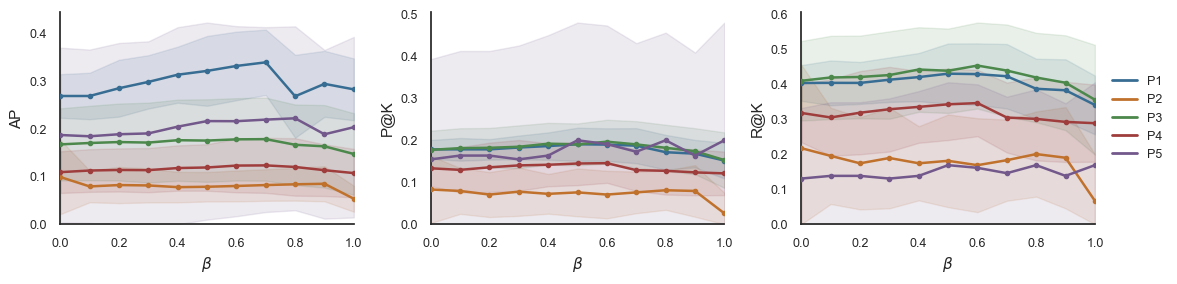

In [ ]:

records = parse_log(LOG_PATH)

print(f"Parsed {len(records)} blocks:")
for r in sorted(records, key=lambda x: (x["pilot"], x["beta"])):
    print(f"  {r['pilot']}  β={r['beta']:.1f}  "
          f"AP={r.get('AP_mean', float('nan')):.3f}±{r.get('AP_std', float('nan')):.3f}  "
          f"P@K={r.get('PK_mean', float('nan')):.3f}±{r.get('PK_std', float('nan')):.3f}  "
          f"R@K={r.get('RK_mean', float('nan')):.3f}±{r.get('RK_std', float('nan')):.3f}")

plot(records, save_path=SAVE_PATH)

# R3. Semantic module

### Intrinsic behaviour

In [27]:
PILOT_CONFIG = {
    "Delos": {
        "data_path": "../data/Delos",
        "model_path": r"C:\Users\Lidia\GitHub\Itefi_Argus\models\checkpoints\final_june_delos\final_june.pt",
    },
    "Baltanas": {
        "data_path": "../data/Baltanas",
        "model_path": r"C:\Users\Lidia\GitHub\Itefi_Argus\models\checkpoints\final_4dil_rmsbn16_baltanas\final_4dil_rmsbn16.pt",
    },
    "Lucretili": {
        "data_path": "../data/Lucretili",
        "model_path": r"C:\Users\Lidia\GitHub\Itefi_Argus\models\checkpoints\final_june_lucretili\final_june.pt",
    },
    "Ranverso": {
        "data_path": "../data/Ranverso",
        "model_path": r"C:\Users\Lidia\GitHub\Itefi_Argus\models\checkpoints\final_june_ranverso\final_june.pt",
    },
    "Schenkenberg": {
        "data_path": "../data/Schenkenberg",
        "model_path": r"C:\Users\Lidia\GitHub\Itefi_Argus\models\checkpoints\final_june_schenkenberg\final_june.pt",
    },
}


SITE_TH_DATA = {
        "delos": { # CHECK: rain thresholds to be fixed 
            "R1a_rain_1h": 10, "R1b_rain_3h": 20,  
            "R2_wind": 12, #12 too low but 20 too high
            "R3_hum_th": 75, "R3_cross": 9,  # 10 to low
        },
        "baltanas": { # CHECK: airflow range 0.1 or 0.05
            "R1_ppv": 0.25, #OK
            "R2_hum_daily_range": 10, #indice the cellars 
            "R3_gnss_change": 0.1, # 0.3 too high 
            "R4a_soil_high": 70, "R4b_soil_daily_range": 3, #OK, no soil high but ok
            "R5a_airflow_const": 0.000001, "R5b_airflow_range": 0.05, # .001 too low;  and 0.1 too high; retry 0.0005 and 0.05
        },
        
        "lucretili": {
            "R1a_crack_step": 0.6, "R1b_crack_offset": 0.5, # 0.1 for step to low; 
            "R2a_tilt_step": 0.2, "R2b_tilt_offset": 0.2,  #0.1 for offset and step to low; 
            "R3_vib_zscore": 7, #OK
            "R4a_hum_spike_6h": 97, "R4b_hum_persist_7d": 90, "R4c_hum_rapid_1h": 20, #too high 100, 100, 20
            "R5_visitors_peak": 20, # OK
            "R6a_rain_1h": 5, "R6a_rain_24h": 20, "R6b_rain_cum7d": 50, #40 acum to low
            "R7a_wind_peak_ratio": 15, # 20 too low 
            "R8_baro_range": 600, # 300 to low # before 3000
            "R9a_temp_high_st": 35, "R9b_temp_high_lt": 25, "R9c_temp_drop_st": 30, "R9d_temp_drop_lt": 5, # a: 25 high; b OK; c: 32 high; d: 5 OK
            "R10_solar_zscore": 3, # 3
        },
        "ranverso": {
            "R1_hum_inside": 80, # 80 OK
            'R2_rain_7d_diff': 20, # 70 too high
            "R3_temp_nodiff": 5, # 5 too high but kept bc otherwise no sense
            "R4a_soil_high": 60, "R4b_soil_low": 5, # 90 too high but ok; 30 too low (all below)
            #"R5a_airflow_high": 1.0, "R5b_airflow_low": 0., #eliminated bc no AF in there
        },
        "schenkenberg": {
            "R1_temp_low": 5, "R1_hum_high": 90, # non bc summer
            "R2_crack_step": 0.1, # 0.1 too high, 7 to low
            "R3_vib_zscore": 3, # OK
            "R4_pga": 3,  # No GNSS
            "R5a_soil_high": 95,  "R5b_soil_range": 1, # problem with values
        },
    }

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------------
# COLORS
# -----------------------------------
colors = {
    "AR": "#8954B8",
    "B": "#933838",
    "NS": "#54A68B"
}

# -----------------------------------
# METRIC MAPPING
# -----------------------------------
metric_cols = ["AR_orig", "B_orig", "S_orig"]

# -----------------------------------
# CONVERTER: iag -> DataFrame
# -----------------------------------
def diag_to_df(iag):

    rows = []

    for rule_name, metrics in iag.items():

        rows.append({
            "rule": rule_name,
            "AR_orig": metrics.get("activation_rate", np.nan),
            "B_orig": metrics.get("burstiness", np.nan),
            "S_orig": metrics.get("noise_sensitivity", np.nan),
        })

    return pd.DataFrame(rows)

all_diag = []

for site_name, config in PILOT_CONFIG.items():

    thresholds = SITE_TH_DATA[site_name.lower()]
    print(f"\n===== Processing site: {site_name} =====")

    seed_everything(42)
    with suppress_all(): 
        base_dataset = pp.TimeSeriesData(
            config["data_path"],
            "30 min",
            True,
            threshold_overrides=thresholds
        )

        diag = base_dataset.compute_rule_diagnostics(
            base_dataset.ek_rules[2],
            base_dataset.ek_rules[1]
        )
    print(diag)

    # diag index = rule names
    tmp = diag.copy()

    tmp["rule"] = tmp.index
    tmp["site"] = site_name

    tmp = tmp.rename(columns={
        "activation_rate": "AR_orig",
        "burstiness": "B_orig",
        "noise_sensitivity": "S_orig"
    })

    all_diag.append(
        tmp[["site", "rule", "AR_orig", "B_orig", "S_orig"]]
    )



===== Processing site: Delos =====
              activation_rate  burstiness  noise_sensitivity
R1a_rain_1h          0.001292    0.571682           0.000000
R1b_rain_3h          0.000000         NaN           0.000000
R2_wind              0.011305    0.521165           0.001841
R3_hum_cross         0.008075    0.734859           0.003335
R4_dates             0.001938   -0.147743           0.001470

===== Processing site: Baltanas =====
                    activation_rate  burstiness  noise_sensitivity
R1_ppv                     0.000760   -0.014289           0.000015
R2_hum_daily_range         0.087591    0.815530           0.033577
R3_gnss_change             0.000000         NaN           0.000000
R4a_soil_high              0.000000         NaN           0.000000
R4b_soil_range             0.000000         NaN           0.000000
R5a_airflow_const          0.000000         NaN           0.007299
R5b_airflow_range          0.014599    0.808871           0.000000
R6_iqr_dates           

            site              rule   AR_orig    B_orig    S_orig
20     Lucretili  R4c_hum_rapid_1h  0.048611  0.728926  0.007631
21     Lucretili       R5_visitors  0.194826  0.772976  0.071436
22     Lucretili          R6a_rain  0.000000       NaN  0.000000
23     Lucretili    R6b_rain_cum7d  0.091575  0.888350  0.000366
24     Lucretili           R7_wind  0.001297  0.192547  0.000221
25     Lucretili           R8_baro  0.276404  0.833339  0.054373
26     Lucretili  R9a_temp_high_st  0.000000       NaN  0.000000
27     Lucretili  R9b_temp_high_lt  0.010989 -1.000000  0.000000
28     Lucretili  R9c_temp_drop_st  0.000000       NaN  0.000000
29     Lucretili  R9d_temp_drop_lt  0.008394  0.745680  0.004976
30     Lucretili  R10_solar_zscore  0.000000       NaN  0.000000
31      Ranverso     R1_hum_inside  0.059717  0.845643  0.009874
32      Ranverso        R2_rain_7d  0.142694 -0.116913  0.000057
33      Ranverso    R3_temp_nodiff  0.000000       NaN  0.000000
34      Ranverso     R4a_

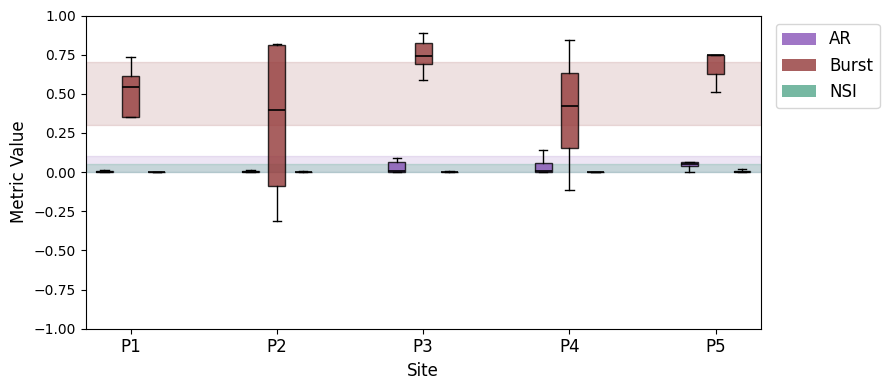

In [123]:
df = pd.concat(all_diag, ignore_index=True)

print(df.tail(20))

metric_cols = ["AR_orig", "B_orig", "S_orig"]

site_order = [
    "Delos",
    "Baltanas",
    "Lucretili",
    "Ranverso",
    "Schenkenberg"
]
gap_info = [
    {
        "AR_low": 0.0,
        "AR_high": 0.2,

        "B_low": 0.3,
        "B_high": 0.7,

        "NS_low": 0.0,
        "NS_high": 0.05,
    }
]
# -----------------------------------
# BUILD GROUPED DATA
# -----------------------------------
groups = []
data = []

for site in site_order:

    subdf = df[df["site"] == site]

    if len(subdf) == 0:
        print(f"[WARN] empty site: {site}")
        continue

    groups.append(site)

    metric_data = []

    for col in metric_cols:

        vals = pd.to_numeric(subdf[col], errors="coerce").dropna().values

        print(site, col, "n =", len(vals))

        metric_data.append(vals)

    data.append(metric_data)

# -----------------------------------
# FLATTEN FOR BOXPLOT (THIS WAS MISSING)
# -----------------------------------
flat_data = []
positions = []

n_metrics = 3
within_spacing = 0.7
between_spacing = 1.8

for i, metric_data in enumerate(data):

    base = i * (n_metrics * within_spacing + between_spacing)

    for j in range(n_metrics):

        flat_data.append(metric_data[j])
        positions.append(base + j * within_spacing)

# DEBUG CHECK
print("\nFLAT DATA SIZES:")
for i, arr in enumerate(flat_data):
    print(i, len(arr))

# -----------------------------------
# PLOT
# -----------------------------------
fig, ax = plt.subplots(figsize=(9, 4))

bp = ax.boxplot(
    flat_data,
    positions=positions,
    patch_artist=True,
    showfliers=False,
    widths=0.45,
    medianprops=dict(color="black", linewidth=1.2)
)

# -----------------------------------
# COLORS
# -----------------------------------
for i, box in enumerate(bp["boxes"]):

    metric_idx = i % 3

    label = ["AR", "B", "NS"][metric_idx]

    box.set_facecolor(colors[label])
    box.set_alpha(0.8)

# -----------------------------------
# X LABELS
# -----------------------------------
centers = []

for i in range(len(groups)):

    base = i * (n_metrics * within_spacing + between_spacing)
    centers.append(base + (n_metrics - 1) * within_spacing / 2)

ax.set_xticks(centers)
ax.set_xticklabels([f"P{i+1}" for i in range(len(groups))], fontsize=12)

for g in gap_info:

    ax.axhspan(g["AR_low"], g["AR_high"]-0.1,
               color=colors["AR"], alpha=0.15)

    ax.axhspan(g["B_low"], g["B_high"],
               color=colors["B"], alpha=0.15)

    ax.axhspan(g["NS_low"], g["NS_high"],
               color=colors["NS"], alpha=0.25)


# -----------------------------------
# LEGEND
# -----------------------------------
legend = [
    Patch(facecolor=colors["AR"], label="AR", alpha=0.8),
    Patch(facecolor=colors["B"], label="Burst", alpha=0.8),
    Patch(facecolor=colors["NS"], label="NSI", alpha=0.8),
]

ax.legend(handles=legend, loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=12)

ax.set_ylabel("Metric Value", fontsize=12)
ax.set_xlabel("Site", fontsize=12)
plt.ylim(-1, 1)
plt.tight_layout()
plt.show()

### Complementarity

In [33]:
def evaluate_site(site_name, config, ths, device="cpu"):
    print(f"\n===== Processing site: {site_name} =====")

    seed_everything(42)

    with suppress_all():
        base_dataset = pp.TimeSeriesData(config["data_path"],"30 min",True, threshold_overrides= ths)
        pre_ds = pp.TSDataset("both",base_dataset.raw_df_with_alive.copy(),base_dataset.raw_df_with_alive.columns.tolist(), 
                            72, 0.1, 0.1,positive=base_dataset.ek_rules[0].max(axis=1))

        scale=pre_ds.feat_scale
        pre_ds.mode = "train"
        pre_ds.current_data = pre_ds.all_data["train"]
        train_loader= DataLoader(pre_ds, batch_size=256, shuffle=False) 
        pre_ds.mode = "val"
        pre_ds.current_data = pre_ds.all_data["val"]
        val_loader = DataLoader(pre_ds, batch_size=256,shuffle=False)
        pre_ds.mode = "test"
        pre_ds.current_data = pre_ds.all_data["test"]
        test_loader= DataLoader(pre_ds, batch_size=1, shuffle=False)
    
    print("total anomaly points", (base_dataset.ek_rules[0].max(axis=1) > 0.5).sum())
    model_args = { "data_dim": pre_ds.n_features,"hidden_dim": 32,"dropout": 0.3,}
    model = models.SerializableModule().create("NestedAD", **model_args)
    state_dict = torch.load( config["model_path"], map_location=device)
    model.load_state_dict(state_dict, strict=False)
    model.to(device)

    train_scores, train_labels =    get_scores(model, train_loader, beta=0.5, revin=True, rec_refs=scale, fc_refs=scale, block_attn=False, block_tcn=False, return_outputs="labels")
    val_scores, val_labels =        get_scores(model, val_loader, beta=0.5, revin=True, rec_refs=scale, fc_refs=scale, block_attn=False,block_tcn=False,return_outputs="labels")
    test_scores, test_labels =      get_scores(model, test_loader, beta=0.5,revin=True, rec_refs=scale, fc_refs=scale, block_attn=False,block_tcn=False,return_outputs="labels")

    train_val_scores = np.concatenate([train_scores, val_scores],axis=0)
    threshold = compute_threshold(train_val_scores)

    all_scores = np.concatenate([train_scores, val_scores, test_scores], axis=0)
    all_labels_sem = np.concatenate( [train_labels, val_labels, test_labels], axis=0)
    all_labels_dl = (all_scores > threshold).astype(int)


    true_neg  = (all_labels_sem == 0) & (all_labels_dl == 0)
    sem_only  = (all_labels_sem == 1) & (all_labels_dl == 0)
    dl_only   = (all_labels_sem == 0) & (all_labels_dl == 1)
    both      = (all_labels_sem == 1) & (all_labels_dl == 1)
    
    print(true_neg.sum(), sem_only.sum(), dl_only.sum(), both.sum())

    # 1. Complementarity index (you already have this — proportion of semantic
    #    alarms missed by DL, i.e. sem_only / total_sem)
    comp_idx = sem_only.sum() / all_labels_sem.sum()

    # 2. Score percentile of semantic points within the FULL score distribution
    #    → if truly invisible to DL, semantic scores should sit at ~50th percentile
    #    → if redundant, they would sit at 90th+
    sem_scores    = all_scores[all_labels_sem == 1]
    all_scores_sorted = np.sort(all_scores)
    percentiles   = np.searchsorted(all_scores_sorted, sem_scores) / len(all_scores_sorted)
    median_pctile = np.median(percentiles)

    # 3. Effect size (Cohen's d) between sem=1 scores and true negatives
    #    → small effect size = DL genuinely doesn't see those events
    #    → avoids KS sample-size sensitivity
    mu_sem   = all_scores[sem_only].mean()
    mu_neg   = all_scores[true_neg].mean()
    std_pool = np.sqrt((all_scores[sem_only].var() + all_scores[true_neg].var()) / 2)
    cohens_d = (mu_sem - mu_neg) / (std_pool + 1e-8)

    print(f"Complementarity index : {comp_idx:.3f}")
    print(f"Median score percentile of semantic anomalies: {median_pctile:.3f}")
    print(f"Cohen's d (sem_only vs true-neg): {cohens_d:.3f}")


In [36]:
for site_name, config in PILOT_CONFIG.items():
    thresholds = SITE_TH_DATA[site_name.lower()]
    evaluate_site(site_name, config, thresholds)


===== Processing site: Delos =====
total anomaly points 590

 Using fixed threshold on TRAIN ONLY
Final threshold: 0.0486 

3174 255 66 0
Complementarity index : 1.000
Median score percentile of semantic anomalies: 0.337
Cohen's d (sem_only vs true-neg): -0.559

===== Processing site: Baltanas =====
total anomaly points 702

 Using fixed threshold on TRAIN ONLY
Final threshold: 0.0702 

1089 558 24 81
Complementarity index : 0.873
Median score percentile of semantic anomalies: 0.550
Cohen's d (sem_only vs true-neg): 0.171

===== Processing site: Lucretili =====
total anomaly points 7205

 Using fixed threshold on TRAIN ONLY
Final threshold: 0.0656 

24 3567 0 120
Complementarity index : 0.967
Median score percentile of semantic anomalies: 0.496
Cohen's d (sem_only vs true-neg): -1.256

===== Processing site: Ranverso =====
total anomaly points 2904

 Using fixed threshold on TRAIN ONLY
Final threshold: 0.0475 

1698 1929 93 264
Complementarity index : 0.880
Median score percentile of 

# EXTRA. Plots

### Injected anomalies examples

In [ ]:
def detect_periodic_features_multi(values, period_len, threshold=0.25):
    N, F = values.shape
    periodic_features = []

    for f in range(F):
        if N <= period_len:
            continue

        x = values[:, f]

        if np.std(x) < 1e-6:
            continue

        def autocorr(lag):
            if lag <= 0 or lag >= N:
                return 0
            x1 = x[:-lag]
            x2 = x[lag:]
            if np.std(x1) < 1e-6 or np.std(x2) < 1e-6:
                return 0
            return np.corrcoef(x1, x2)[0, 1]

        acf_p = autocorr(period_len)
        acf_half = autocorr(period_len // 2)
        acf_near = max(autocorr(period_len - period_len//6), autocorr(period_len + period_len//6))

        c1 = acf_p > threshold 
        c2 = acf_p > acf_half + 0.05
        c3 = acf_p > acf_near
        
        # periodicity condition
        if (c1 and c2 and c3):
            periodic_features.append(f)

    return periodic_features



def inject_controlled_anomalies(
    test_clean,
    lb=48,
    seed=42,
    sev=0.5,

):
    """
    Inject one anomaly per subtype using a minimal taxonomy:
    - Collective: shift, variance_burst, trend_flip
    - Contextual: context_swap (ONLY on periodic features)
    - Point: spike, drop
    """

    np.random.seed(seed)

    test_raw = test_clean.copy()
    N, F = test_raw.shape

    anomaly_indices = []

    # -----------------------------------------------------
    # choose stable features
    # -----------------------------------------------------
    feature_energy = np.std(test_clean, axis=0)
    valid_features = np.where(
        feature_energy > np.percentile(feature_energy, 20)
    )[0]

    # -----------------------------------------------------
    # contextual features must be periodic
    # -----------------------------------------------------
    periodic_features = detect_periodic_features_multi(test_clean, 24)
    print(periodic_features)

    # fallback: if no periodic features exist, skip contextual anomaly
    contextual_enabled = len(periodic_features) > 0

    # -----------------------------------------------------
    # subtype specification
    # -----------------------------------------------------
    specs = [
        # COLLECTIVE
        ("collective", "shift", 300),
        ("collective", "variance_burst", 700),
        ("collective", "frozen", 1100),
    ]

    # add contextual only if periodic features exist
    if contextual_enabled:
        specs.append(("contextual", "context_swap", 1490))

    # POINT
    specs.extend([
        ("point", "spike", 1900),
        ("point", "drop", 2300),
    ])

    # -----------------------------------------------------
    # inject
    # -----------------------------------------------------
    for idx, (atype, mode, center) in enumerate(specs):

        # choose feature
        if atype == "contextual":
            f = np.random.choice(periodic_features)
        else:
            f = valid_features[idx % len(valid_features)]

        local_std = np.std(
            test_clean[max(0, center - 100):center, f]
        ) + 1e-6

        # ---------------------------------------------
        # COLLECTIVE
        # ---------------------------------------------
        if atype == "collective":

            seg_len = 24
            s = center - seg_len // 2
            e = center + seg_len // 2
            seg = test_raw[s:e, f].copy()

            if mode == "shift":
                test_raw[s:e, f] = seg + 4 * sev * local_std
                print(f)

            elif mode == "variance_burst":
                noise = np.random.normal(0, 2 * sev * local_std, seg_len)
                test_raw[s:e, f] = seg + noise
                print(f)

            elif mode == "frozen":
                test_raw[s:e, f] = seg[0]
                print(f)

        # ---------------------------------------------
        # CONTEXTUAL (only periodic features)
        # ---------------------------------------------
        elif atype == "contextual":

            seg_len = 3
            s = center - 1
            e = center + 2
            if mode == "context_swap":

                f=12
                half_period = 24 // 2

                # choose +half or -half
                if np.random.rand() < 0.5:
                    donor_center = center + half_period
                else:
                    donor_center = center - half_period

                # clip to valid range
                donor_center = np.clip(donor_center, 1, N - 2)
                print(s, donor_center)

                # donor window of 3 points
                donor_window = test_raw[donor_center - 1 : donor_center + 2, f]

                # inject donor window
                test_raw[s:e, f] = donor_window

        # ---------------------------------------------
        # POINT
        # ---------------------------------------------
        elif atype == "point":

            s = center
            e = center + 1

            if mode == "spike":
                f=13
                test_raw[center, f] += 4 * sev * local_std
                print(f)

            elif mode == "drop":
                test_raw[center, f] -= 4 * sev * local_std
                print(f)

        # ---------------------------------------------
        # register anomaly
        # ---------------------------------------------
        anomaly_indices.append({
            "type": atype,
            "mode": mode,
            "start": s,
            "end": e,
            "center": center,
            "features": (f,),
        })

    return test_raw, anomaly_indices



# PLOT


def plot_one_per_subtype(
    test_clean,
    test_raw,
    anomaly_indices,
    lb=48,
):

    grouped = defaultdict(lambda: defaultdict(list))

    for a in anomaly_indices:
        grouped[a["type"]][a["mode"]].append(a)

    fig, axes = plt.subplots(2, 3, figsize=(12, 7))

    # =====================================================
    # ROW 1: 2 POINT + 1 CONTEXTUAL
    # =====================================================
    layout = [
        [
            ("collective", "shift"),
            ("collective", "variance_burst"),
            ("collective", "frozen"),
        ],
        [
            ("contextual", "context_swap"),
            ("point", "spike"),
            ("point", "drop"),
        ],
    ]

    for r, row in enumerate(layout):
        for c, (ttype, mode) in enumerate(row):

            ax = axes[r, c]

            entries = grouped[ttype].get(mode, [])
            if len(entries) == 0:
                ax.axis("off")
                continue

            entry = entries[0]

            start = max(0, entry["center"] - lb)
            end = min(test_raw.shape[0], entry["center"] + lb)

            x = np.arange(start, end)

            # clean
            ax.plot(
                x,
                test_clean[start:end, entry["features"][0]],
                linewidth=2,
                label="Original"
            )

            # injected
            ax.plot(
                x,
                test_raw[start:end, entry["features"][0]],
                linestyle="--",
                color="red",
                linewidth=2,
                label="Injected"
            )

            # anomaly region
            ax.axvspan(
                entry["start"],
                entry["end"],
                color="grey",
                alpha=0.2
            )
            ax.set_ylabel("Scaled feature value")
            ax.set_xlabel("Time point index")
            ax.set_title(f"{ttype}\n{mode}", fontsize=12)
            ax.grid(False)
            

    axes[1, 2].legend(fontsize=10)
    plt.tight_layout()
    plt.show()



===== Processing site: Delos =====
[0, 3, 4, 9, 12, 14, 18, 21, 22, 24, 25, 26, 27, 29, 30, 31, 33, 35, 37, 38]
0
1
2
1489 1478
13
5


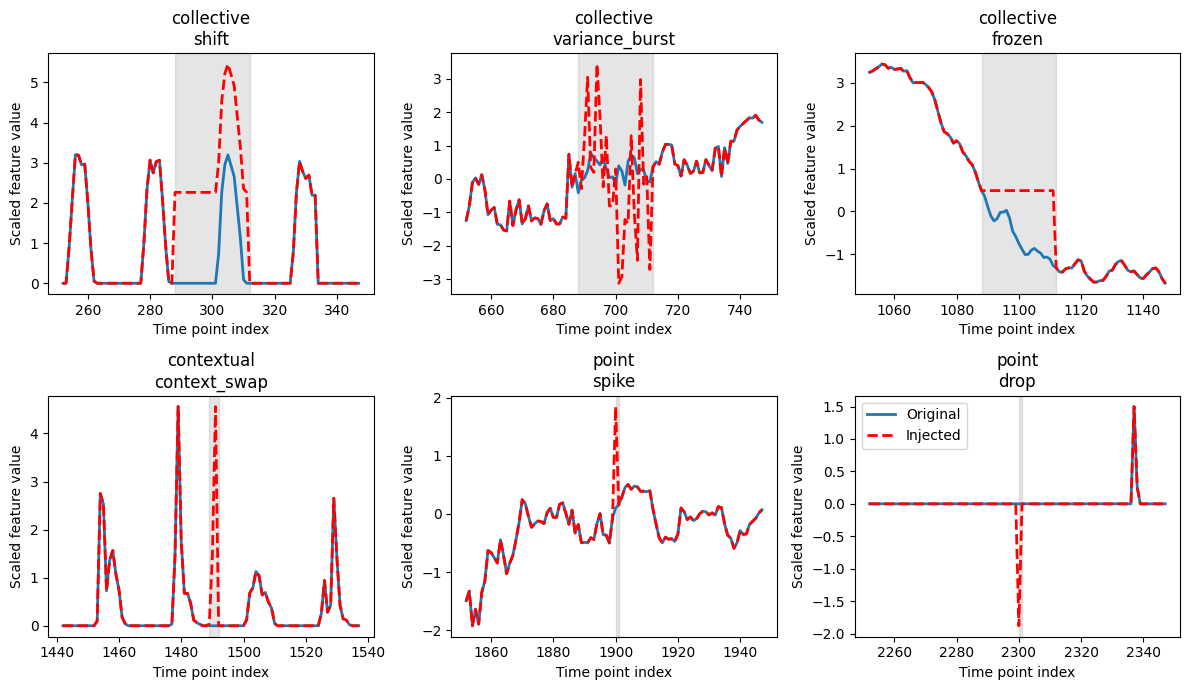

In [ ]:

pilot_sites = {"Delos": {  "data_path": "../data/Delos",},}


for site, paths in pilot_sites.items():
    print(f"\n===== Processing site: {site} =====")
    with suppress_all():
        data_path = paths["data_path"]
        base_dataset = pp.TimeSeriesData(data_path, "1h", True)
        pre_ds = pp.TSDataset( "both", base_dataset.raw_df_with_alive.values, base_dataset.feature_names, 72, 0.05, 0.9, positive=base_dataset.ek_rules[0].max(axis=1))
    test_clean = pre_ds.test_clean.copy()

    test_raw, anomaly_indices = inject_controlled_anomalies(
        test_clean,
        lb=48,
        seed=42,
    )

    plot_one_per_subtype(
        test_clean=test_clean,
        test_raw=test_raw,
        anomaly_indices=anomaly_indices,
        lb=48,
    )

### Dataset exploration

In [63]:


pilot_sites = {
      "Delos": {
        "data_path": "../data/Delos",
    },
    "Baltanas": {
        "data_path": "../data/Baltanas",
    },
    "Lucretili": {
        "data_path": "../data/Lucretili",
    },
    "Ranverso": {
        "data_path": "../data/Ranverso",
    },
    "Schenkenberg": {
        "data_path": "../data/Schenkenberg",
    },
}


all_datasets = {}

for site, paths in pilot_sites.items():
    print(f"\n===== Processing site: {site} =====")

    with suppress_all():
        device = "cpu"
        seed_everything(42)
        dataset = pp.TimeSeriesData(paths["data_path"],"1h", True,)
        all_datasets[site] = dataset
        
    print(dataset.feature_names)
    df = dataset.raw_df

    # Correlation matrix
    corr = df.corr(method="spearman")

    pairs = []

    for i in range(len(corr.columns)):
        for j in range(i + 1, len(corr.columns)):

            c1 = corr.columns[i]
            c2 = corr.columns[j]

            # Extract sensor IDs (first 6 chars before "_")
            sid1 = c1.split("_")[0]
            sid2 = c2.split("_")[0]

            # Skip same sensor
            if sid1 == sid2:
                continue

            val = corr.iloc[i, j]

            if pd.notna(val):
                pairs.append((c1, c2, val, abs(val)))

    # Sort by absolute correlation
    pairs = sorted(pairs, key=lambda x: x[3], reverse=True)

    print(f"\nTop 20 correlations for {site}:")
    for c1, c2, corr_val, _ in pairs[:20]:
            print(f"{corr_val:+.3f} | {c1} <-> {c2}")




===== Processing site: Delos =====
['300548_uv', '300548_baro', '300548_hum1', '300548_light', '300548_rain_1', '300548_temp1', '300548_wind_peak_1', '300548_wind_speed_1', '800035_peoplecount', '151805_h_masks_in_room217_hum', '151805_h_masks_in_room217_therm', '151805_h_masks_in_room217_lux', '151809_h_masks_in_room216_hum', '151809_h_masks_in_room216_therm', '151809_h_masks_in_room216_lux', '151836_h_masks_in_room214_hum', '151836_h_masks_in_room214_therm', '151836_h_masks_in_room214_lux', '168439_h_masks_in_room215_hum', '168439_h_masks_in_room215_therm', '168439_h_masks_in_room214_lux', '149423_h_masks_in_room215_1_soil_moisture', '149368_h_masks_in_room215_2_soil_moisture', '149460_h_masks_out_soil_moisture', '149529_h_fournoi_in_mosaic_soil_moisture', '151815_h_fournoi_out_hum', '151815_h_fournoi_out_therm', '151815_h_fournoi_out_soil_moisture', '151815_h_fournoi_out_pyr', '150900_tilt1_x', '150900_tilt1_y', '150900_tilt1_z', '153157_tilt2_y', '153157_tilt2_x', '153157_tilt2_z'

In [70]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import spearmanr


time_windows = {
    "Delos": ("2026-01-15", "2026-02-15"),
    "Baltanas": ("2026-03-14", "2026-04-14"),
    "Lucretili": ("2026-03-20", "2026-04-20"),
    "Ranverso": ("2026-02-20", "2026-03-20"),
    "Schenkenberg": ("2026-05-24", "2026-06-22"),
}


selected_features = {
    "Delos": ["149368_h_masks_in_room215_2_soil_moisture", "151805_h_masks_in_room217_hum", "300548_rain_1", "800035_peoplecount",],
    "Baltanas": ["7020c8_temperatura mín.", "130432_c88_sisa_soil_temp", "4d7f09_v_in", "159313_c364_acc_ext_ppv_x",], 
    "Lucretili": ["177281_mont_hum", "153061_conv_tilt2_z","450308_counter_in",  "177310_mont_crack1"],
    "Ranverso": ["174188_in_back_hum", "143276_altar_tilt_x", "149361_out_pyran", "359111_pm10"],
    "Schenkenberg": ["300266_temp1", "152899_tilt2_x", "149796_crack", "152555_acc2_freq3y"],
}


feature_labels = {
    "Delos": {
        "149368_h_masks_in_room215_2_soil_moisture": "Soil moisture (%)",
        "151805_h_masks_in_room217_hum": "Humidity (%)",
        "300548_rain_1": "Rain (mm/h)",
        "800035_peoplecount": "People counter (#)",
    },
    "Baltanas": {
        "7020c8_temperatura mín.": "Temperature (ºC)",
        "130432_c88_sisa_soil_temp": "Internal Temp. (ºC)",
        "4d7f09_v_in": "Vehicle counter (#)",
        "159313_c364_acc_ext_ppv_x": "PPV (mm/s)",
    },
    "Lucretili": {
        "177281_mont_hum": "Humidity (%)",
        "153061_conv_tilt2_z": "Tiltmeter (º)",
        "450308_counter_in": "People counter (#)",
        "177310_mont_crack1": "Crackmeter (mm)",
    },
    "Ranverso": {
        "174188_in_back_hum": "Humidity (%)",
        "143276_altar_tilt_x": "Tiltmeter (º)",
        "149361_out_pyran": "Pyranometer (W/m²)",
        "359111_pm10": "PM10 (μg/m³)",
    },
    "Schenkenberg": {
        "300266_temp1": "Temperature (ºC)",
        "152899_tilt2_x": "Tiltmeter (º)",
        "149796_crack": "Crackmeter (mm)",
        "152555_acc2_freq3y": "PGA-Freq (Hz)",
    }
}



# --------------------------------------------------
# COLOR GROUPS
# --------------------------------------------------
green_features = {"Rain (mm/h)", "Humidity (%)", "Temperature (ºC)", "UV (W/m²)", "Bar. Pressure (hPa)", "Thermistor (ºC)", "Pyranometer (W/m²)", "PM10 (μg/m³)"}
blue_features = {"Soil moisture (%)", "Soil Moisture (%)", "PPV (mm/s)", "Crackmeter (mm)", "Tiltmeter (º)", "PGA-Freq (Hz)", "Internal Temp. (ºC)"}
royalblue_features = {"People counter (#)", "Vehicle counter (#)"}

def get_feature_color(label):
    if label in green_features:
        return "#58983A"
    elif label in blue_features:
        return "#2D9ECF"
    elif label in royalblue_features:
        return "#D47C10"
    return "black"


===== Processing site: Delos =====
Selected features: ['149368_h_masks_in_room215_2_soil_moisture', '151805_h_masks_in_room217_hum', '300548_rain_1', '800035_peoplecount']

===== Processing site: Baltanas =====
Selected features: ['7020c8_temperatura mín.', '130432_c88_sisa_soil_temp', '4d7f09_v_in', '159313_c364_acc_ext_ppv_x']

===== Processing site: Lucretili =====
Selected features: ['177281_mont_hum', '153061_conv_tilt2_z', '450308_counter_in', '177310_mont_crack1']

===== Processing site: Ranverso =====
Selected features: ['174188_in_back_hum', '143276_altar_tilt_x', '149361_out_pyran', '359111_pm10']

===== Processing site: Schenkenberg =====
Selected features: ['300266_temp1', '152899_tilt2_x', '149796_crack', '152555_acc2_freq3y']


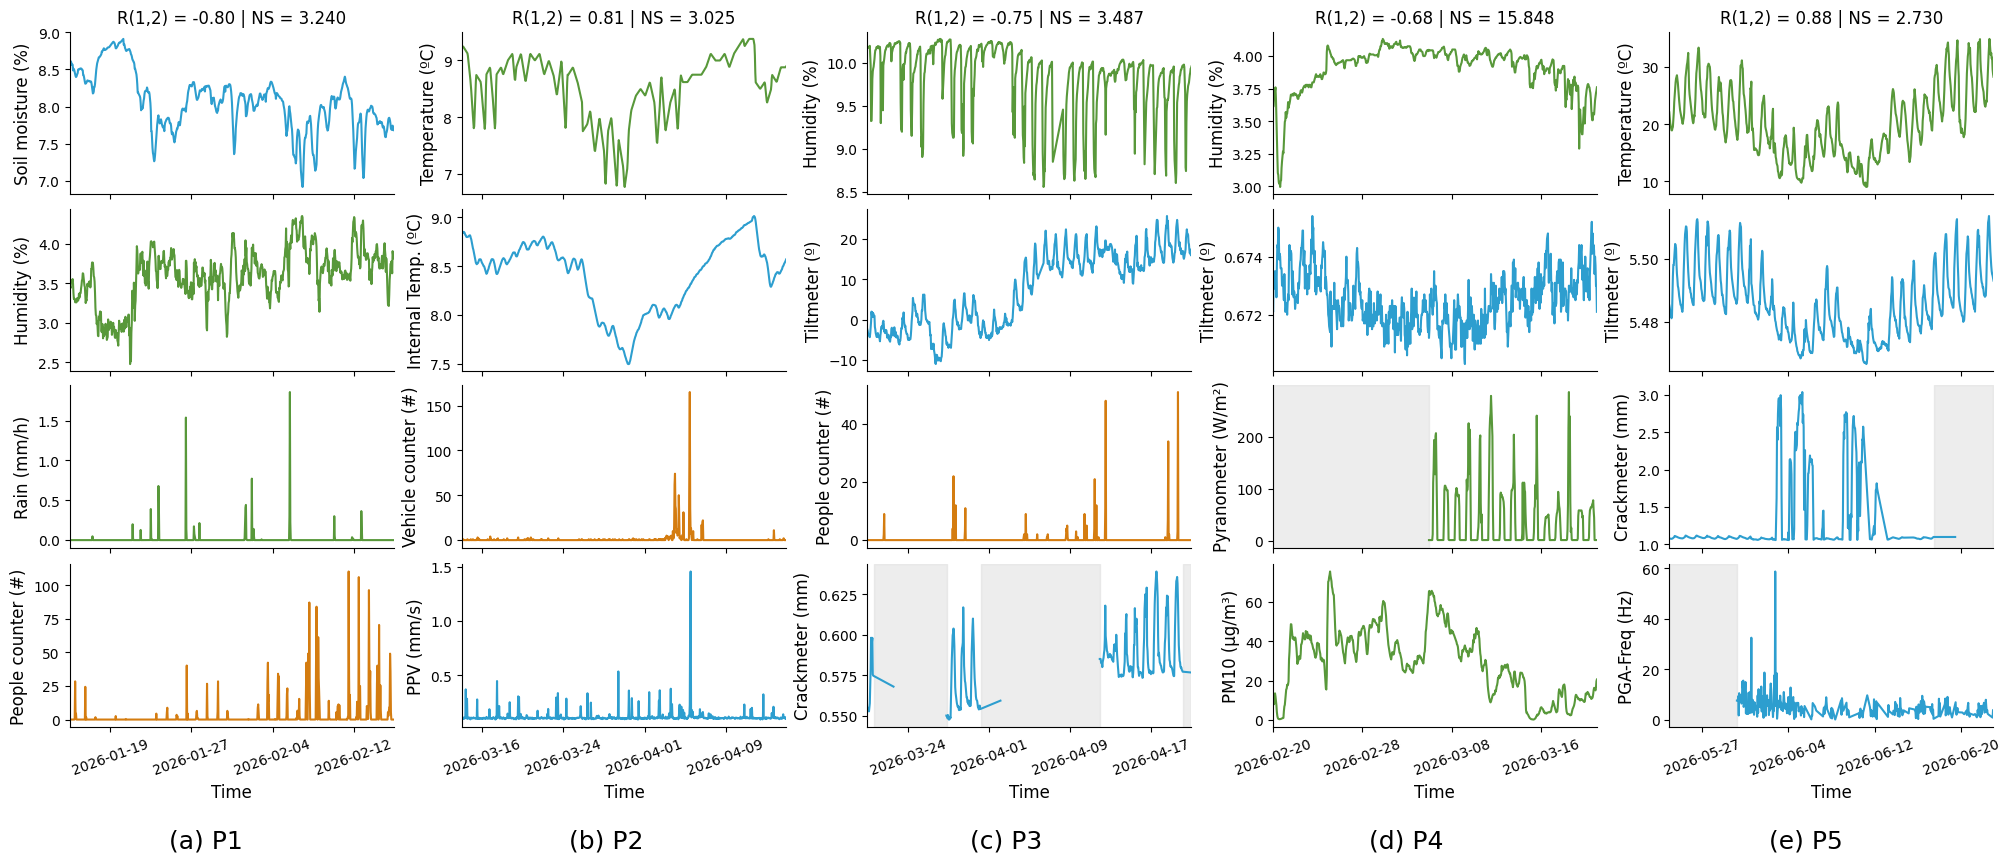

In [71]:
import ruptures as rpt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import spearmanr

sites = list(selected_features.keys())

fig, axes = plt.subplots(
    nrows=4,
    ncols=len(sites),
    figsize=(4 * len(sites), 8),
    sharex=False,
    constrained_layout=True
)

for col_idx, site in enumerate(sites):
    print(f"\n===== Processing site: {site} =====")
    print(f"Selected features: {selected_features[site][:4]}")

    dataset = all_datasets[site]
    df = dataset.raw_df.copy()
    df_alive = dataset.raw_df_with_alive.copy()

    start_time, end_time = time_windows[site]
    df_window = df.loc[start_time:end_time]
    df_alive_window = df_alive.loc[start_time:end_time]

    features = selected_features[site][:4]


    corr_matrix = np.full((len(features), len(features)), np.nan)

    for i, f1 in enumerate(features):
        for j, f2 in enumerate(features):

            tmp = df_window[[f1, f2]].dropna()

            if len(tmp) > 10:
                x = tmp[f1]
                y = tmp[f2]

                if isinstance(x, pd.DataFrame):
                    x = x.iloc[:, 0]
                if isinstance(y, pd.DataFrame):
                    y = y.iloc[:, 0]

                x = pd.to_numeric(x.values.ravel(), errors="coerce")
                y = pd.to_numeric(y.values.ravel(), errors="coerce")

                mask = np.isfinite(x) & np.isfinite(y)

                if mask.sum() > 10:
                    corr_matrix[i, j], _ = spearmanr(x[mask], y[mask])


    r12 = np.nan

    if len(features) >= 2:
        tmp = df_window[[features[0], features[1]]].dropna()

        if len(tmp) > 10:
            x = pd.to_numeric(tmp[features[0]], errors="coerce").to_numpy()
            y = pd.to_numeric(tmp[features[1]], errors="coerce").to_numpy()

            mask = np.isfinite(x) & np.isfinite(y)

            if mask.sum() > 10:
                r12, _ = spearmanr(x[mask], y[mask])


    # ==================================================
    # 3. CHANGE POINT DETECTION (GLOBAL)
    # ==================================================
    window = 20

    ns_vals = []

    for feat in features:
        s = pd.to_numeric(df_window[feat], errors="coerce")

        roll_mean = s.rolling(window).mean()
        roll_std = s.rolling(window).std()

        # how unstable stats are over time
        ns = roll_std.std() + roll_mean.std()
        ns_vals.append(ns)

    ns_index = np.nanmean(ns_vals)
    
    
    title_text = f"R(1,2) = {r12:.2f} | NS = {ns_index:.3f}"
    axes[0, col_idx].set_title(title_text, fontsize=12)


    # ==================================================
    # 4. PLOTTING (4 ROWS PER SITE)
    # ==================================================
    for row_idx in range(4):

        ax = axes[row_idx, col_idx]

        if row_idx >= len(features):
            ax.axis("off")
            continue

        feat = features[row_idx]
        label = feature_labels[site].get(feat, feat)
        color = get_feature_color(label)

        series = df_window[feat]
        if "tilt" in feat.lower():
            X=np.round(series / 90)
            series = series - X*90

        # --------------------------------------------------
        # GREY BACKGROUND (MISSING DATA ONLY)
        # --------------------------------------------------
        alive_col = f"{feat}_alive"

        if alive_col in df_alive_window.columns:
            dead_mask = (
                df_alive_window[alive_col]
                .reindex(df_window.index)
                .fillna(0)
                .eq(0)
                .to_numpy()
            )
        else:
            dead_mask = np.zeros(len(df_window), dtype=bool)

        ax.fill_between(
            df_window.index,
            0,
            1,
            where=dead_mask,
            transform=ax.get_xaxis_transform(),
            color="lightgrey",
            alpha=0.4,
            zorder=0
        )

        # --------------------------------------------------
        # SIGNAL
        # --------------------------------------------------
        ax.plot(
            df_window.index,
            series,
            color=color,
            linewidth=1.5,
            zorder=2
        )



        ax.set_xlim(df_window.index.min(), df_window.index.max())

        if row_idx == 3:
            ax.set_xlabel("Time", fontsize=12)
            ax.tick_params(axis="x", labelrotation=20)
        else:
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelbottom=False)

        ax.xaxis.set_major_locator(mticker.MaxNLocator(4))
        ax.set_ylabel(label, fontsize=12)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

# ==================================================
for col_idx, site in enumerate(sites):
    fig.text(
        (col_idx + 0.5) / len(sites),   # center of column
        -0.03,                          # below figure
        f"({chr(97 + col_idx)}) P{col_idx+1}",
        ha="center",
        va="top",
        fontsize=18,
        fontfamily="sans-serif",
        fontname="DejaVu Sans"
    )
plt.show()

### Case study

In [30]:

pilot_sites = {"Delos": {  
    "data_path": "../data/Delos",
    "thresholds" : { # CHECK: rain thresholds to be fixed 
            "R1a_rain_1h": 10, "R1b_rain_3h": 20,  
            "R2_wind": 12, #12 too low but 20 too high
            "R3_hum_th": 75, "R3_cross": 9,  # 10 to low
        },
    },
}


for site, config in pilot_sites.items():
    print(f"\n===== Processing site: {site} =====")

    device = "cpu"
    seed_everything(42)
    data_path = config["data_path"]
    thresholds = config["thresholds"]
    
    base_dataset = pp.TimeSeriesData(data_path,"30 min",True, threshold_overrides= thresholds)
    with suppress_all():
        pre_ds = pp.TSDataset("both",base_dataset.raw_df_with_alive.copy(),base_dataset.raw_df_with_alive.columns.tolist(), 
                            72, 0.1, 0.1,positive=base_dataset.ek_rules[0].max(axis=1), inject_on_init=False)
        
        scale=pre_ds.feat_scale
        pre_ds.mode = "train"
        pre_ds.current_data = pre_ds.all_data["train"]
        train_loader= DataLoader(pre_ds, batch_size=256, shuffle=False) 
        pre_ds.mode = "val"
        pre_ds.current_data = pre_ds.all_data["val"]
        val_loader = DataLoader(pre_ds, batch_size=256,shuffle=False)
        pre_ds.mode = "test"
        pre_ds.current_data = pre_ds.all_data["test"]
        test_loader= DataLoader(pre_ds, batch_size=1, shuffle=False)


===== Processing site: Delos =====
Using data from ../data/Delos

Sensor 149423 removed due to corrupted data in 149423_h_masks_in_room215_1_soil_moisture


In [46]:
    

model_args = {"data_dim": pre_ds.n_features,"hidden_dim": 32,"dropout": 0.3,}

model = models.SerializableModule().create("NestedAD", **model_args)

state_dict = torch.load("C:\\Users\\Lidia\\GitHub\\Itefi_Argus\\models\\checkpoints\\final_june_delos\\final_june.pt", map_location=device)


model.load_state_dict(state_dict,strict=False)
model.to(device)

train_scores = get_scores(model,train_loader,beta=0.5,revin=True, rec_refs=scale, fc_refs=scale, block_attn=False, block_tcn=False, return_outputs=None)
val_scores = get_scores(model,val_loader,beta=0.5,revin=True, rec_refs=scale, fc_refs=scale,  block_attn=False, block_tcn=False, return_outputs=None)
train_val_scores = np.concatenate([train_scores, val_scores], axis=0)
threshold1 = compute_threshold(train_val_scores)
print(f"Threshold (mad): {threshold1}")

threshold2 = np.percentile(train_val_scores, 99)
print(f"Threshold (99th percentile): {threshold2}")

test_scores, rec_last, fc_last = get_scores(model,test_loader,beta=0.5, revin=True, rec_refs=scale, fc_refs=scale, block_attn=False, block_tcn=False,return_outputs="preds",)

# ---------------- DATA ----------------
test_data = pre_ds.all_data["test"]
train_data = pre_ds.all_data["train"]

n_features = len(pre_ds.feature_names)
print(f"Number of features: {n_features}")
lb=72
test_scaled = test_data[lb:, :n_features]
test_alive  = test_data[lb:, n_features:]

train_scaled = train_data[lb:, :n_features]
train_alive  = train_data[lb:, n_features:]

feature_names = pre_ds.feature_names
for i in range(len(feature_names)): 
    print(i, feature_names[i])



 Using fixed threshold on TRAIN ONLY
Final threshold: 0.0486 

Threshold (mad): 0.0486001977162369
Threshold (99th percentile): 0.04774098491834836
Number of features: 55
0 300548_uv
1 300548_baro
2 300548_hum1
3 300548_light
4 300548_rain_1
5 300548_temp1
6 300548_wind_speed_1
7 151805_h_masks_in_room217_hum
8 151805_h_masks_in_room217_therm
9 151805_h_masks_in_room217_lux
10 151809_h_masks_in_room216_hum
11 151809_h_masks_in_room216_therm
12 151809_h_masks_in_room216_lux
13 151836_h_masks_in_room214_hum
14 151836_h_masks_in_room214_therm
15 151836_h_masks_in_room214_lux
16 168439_h_masks_in_room215_hum
17 168439_h_masks_in_room215_therm
18 168439_h_masks_in_room214_lux
19 149368_h_masks_in_room215_2_soil_moisture
20 149405_h_masks_in_room214_airflow
21 109315_h_masks_in_room215_airflow
22 149460_h_masks_out_soil_moisture
23 151815_h_fournoi_out_hum
24 151815_h_fournoi_out_soil_moisture
25 151815_h_fournoi_out_pyr
26 150900_tilt1_x
27 150900_tilt1_y
28 150900_tilt1_z
29 153157_tilt2_

n_features (real, total): 55
n_maskable (real features with alive tracking): 49
EK raw > 0.5 (full test): 8
Distinct active-rule counts: [0 1]

Feature index reference (use this to pick include_indices):
0 300548_uv
1 300548_baro
2 300548_hum1
3 300548_light
4 300548_rain_1
5 300548_temp1
6 Wind Speed S1 (m/s)
7 Hum H1 (%)
8 Temp H1 (°C)
9 151805_h_masks_in_room217_lux
10 Hum H2 (%)
11 Temp H2 (°C)
12 151809_h_masks_in_room216_lux
13 Hum H3 (%)
14 Temp H3 (°C)
15 151836_h_masks_in_room214_lux
16 Hum H4 (%)
17 Temp H4 (°C)
18 168439_h_masks_in_room214_lux
19 149368_h_masks_in_room215_2_soil_moisture
20 149405_h_masks_in_room214_airflow
21 109315_h_masks_in_room215_airflow
22 149460_h_masks_out_soil_moisture
23 151815_h_fournoi_out_hum
24 151815_h_fournoi_out_soil_moisture
25 Pyranometer (W/m²)
26 150900_tilt1_x
27 150900_tilt1_y
28 150900_tilt1_z
29 153157_tilt2_y
30 153157_tilt2_x
31 153157_tilt2_z
32 153242_tilt3_x
33 153242_tilt3_y
34 153242_tilt3_z
35 153295_tilt4_x
36 153295_tilt4_

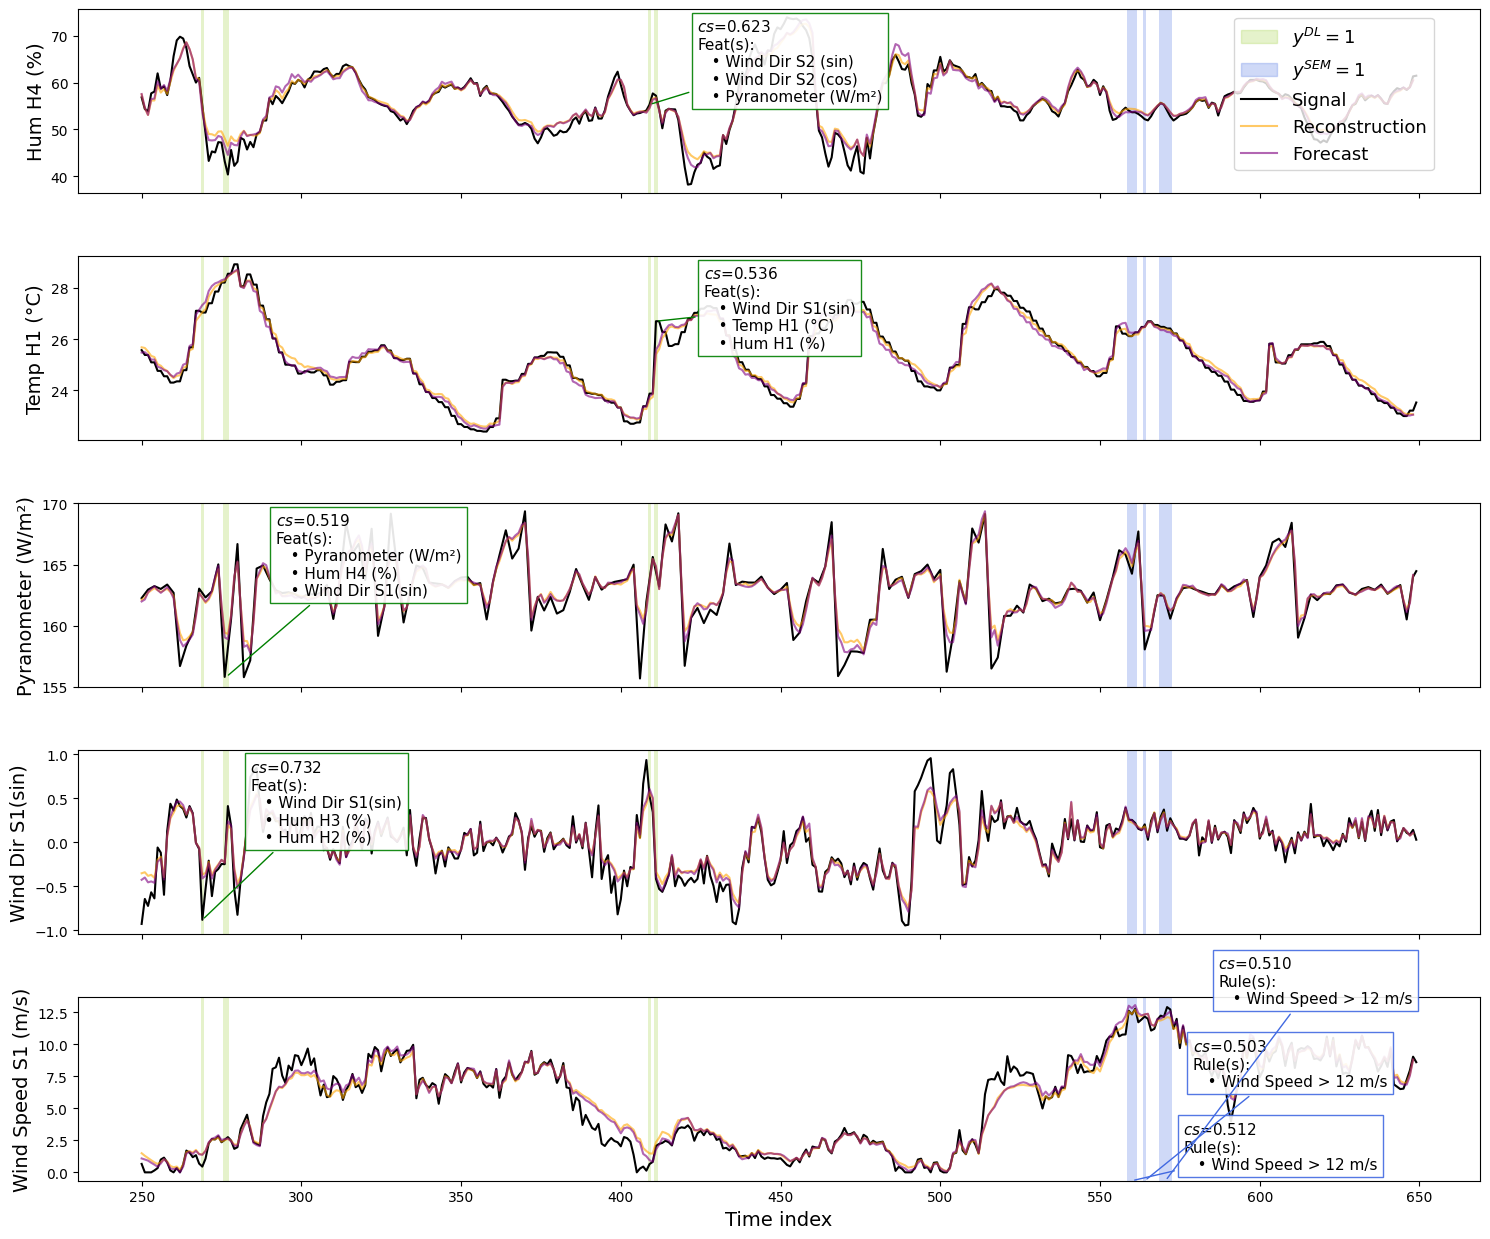

In [ ]:
test_scores = np.asarray(test_scores).flatten()
test_scores = np.abs(test_scores[:-1])
test_scores = np.nan_to_num(test_scores, nan=0.0, posinf=0.0, neginf=0.0)

n_maskable = train_alive.shape[1]
print(f"n_features (real, total): {n_features}")
print(f"n_maskable (real features with alive tracking): {n_maskable}")

rec_diff = np.abs(test_scaled[:-1, :n_maskable] - rec_last)
fc_diff  = np.abs(test_scaled[:-1, :n_maskable] - fc_last)

test_inv = np.zeros_like(test_scaled)
rec_last_inv = np.zeros_like(rec_last)
fc_last_inv  = np.zeros_like(fc_last)

for f in range(n_maskable):
    scaler_f = pre_ds.fitted_scalers.get(f)
    if scaler_f is None:
        test_inv[:, f] = test_scaled[:, f]
        rec_last_inv[:, f] = rec_last[:, f]
        fc_last_inv[:, f] = fc_last[:, f]
        continue

    test_inv[:, f] = scaler_f.inverse_transform(test_scaled[:, f].reshape(-1, 1)).flatten()
    rec_last_inv[:, f] = scaler_f.inverse_transform(rec_last[:, f].reshape(-1, 1)).flatten()
    fc_last_inv[:, f]  = scaler_f.inverse_transform(fc_last[:, f].reshape(-1, 1)).flatten()

T = min(len(test_inv), len(test_scores), len(rec_last_inv), len(fc_last_inv))

test_inv     = test_inv[:T]
test_scores  = test_scores[:T]
rec_last_inv = rec_last_inv[:T]
fc_last_inv  = fc_last_inv[:T]
rec_diff     = rec_diff[:T]
fc_diff      = fc_diff[:T]

x = np.arange(T)

start_T = 250
end_T = 650
x_w = np.arange(start_T, end_T)
threshold = threshold1
anomaly_mask_full = test_scores > threshold
ek_df_full = base_dataset.ek_rules[0]
ek_df = ek_df_full.iloc[pre_ds.test_idx]
ek_raw = ek_df.max(axis=1).to_numpy()
sem_mask = ek_raw > 0.5
sem_counts = (ek_df > 0.5).sum(axis=1).to_numpy()

print("EK raw > 0.5 (full test):", np.sum(sem_mask))
print("Distinct active-rule counts:", np.unique(sem_counts))

RULE_DESCRIPTIONS = {
    "R2_wind": "Wind Speed > 12 m/s",
    # "R1a_rain_1h": "Rain (1h) > 10 mm",
    # "R1b_rain_3h": "Rain (3h) > 20 mm",
    # "R3_hum_th": "Humidity > 75%",
}


def pretty_rule(name):
    return RULE_DESCRIPTIONS.get(name, name)

feature_names = list(pre_ds.feature_names[:n_maskable])

include_indices = [16, 8, 25, 44, 6]
pretty_names = {
    16: "Hum H4 (%)",              # 151809... room215 humidity
    10: "Hum H2 (%)",
    13: "Hum H3 (%)",
    7: "Hum H1 (%)",
    8:  "Temp H1 (°C)",
    11:  "Temp H2 (°C)",
    14:  "Temp H3 (°C)",
    17:  "Temp H4 (°C)",            # 151805_h_masks_in_room217_therm
    25: "Pyranometer (W/m²)",
    44: "Wind Dir S1(sin)",          # 300548_wind_direction_1_sin -- unitless cyclic encoding
    46: "Wind Dir S2 (sin)",  
    45: "Wind Dir S2 (cos)",  
    6:  "Wind Speed S1 (m/s)",
}


for idx, name in pretty_names.items():
    if idx < len(feature_names):
        feature_names[idx] = name

print("\nFeature index reference (use this to pick include_indices):")
for i, name in enumerate(feature_names):
    print(i, name)

feat_scores = rec_diff + fc_diff  # shape (T, n_maskable)

def get_intervals(mask, t_start, t_end):
    intervals = []
    inside = False
    s = None
    for t in range(t_start, t_end):
        if mask[t] and not inside:
            s = t
            inside = True
        elif (not mask[t]) and inside:
            intervals.append((s, t - 1))
            inside = False
    if inside:
        intervals.append((s, t_end - 1))
    return intervals


def explain_dl_interval(s, e, top_k=3):
    mean_feat = feat_scores[s:e + 1].mean(axis=0)
    contrib = mean_feat / (mean_feat.sum() + 1e-8)
    top_idx = np.argsort(contrib)[::-1][:top_k]

    score = test_scores[s:e + 1].max()
    tail = train_val_scores[train_val_scores > threshold]
    tau = tail.std() if len(tail) > 1 else 1e-8
    tau = max(tau, 1e-8)
    delta = max(score - threshold, 0)
    conf = 0.5 + 0.5 * (1 - np.exp(-delta / tau))

    return {
        "start": s, "end": e,
        "confidence": conf,
        "top_idx": top_idx,
        "features": [feature_names[k] for k in top_idx],
        "contrib": contrib,
    }


def explain_sem_interval(s, e):
    lb_offset = 72
    rule_mean = ek_df.iloc[s + lb_offset: e + 1 + lb_offset].mean(axis=0)
    active = rule_mean[rule_mean > 0.5]
    return {
        "start": s, "end": e,
        "confidence": active.max() if len(active) else 0.0,
        "rules": active.sort_values(ascending=False).index[:3].tolist(),
        "rule_scores": active,
    }


dl_intervals_full = get_intervals(anomaly_mask_full, 0, T)
dl_info_full = [explain_dl_interval(s, e) for s, e in dl_intervals_full]

lb_offset = 72
sem_valid_end = min(T, len(sem_mask) - lb_offset)
sem_shifted_mask = sem_mask[lb_offset: lb_offset + sem_valid_end]
sem_intervals_full = get_intervals(sem_shifted_mask, 0, sem_valid_end)
sem_info_full = [explain_sem_interval(s, e) for s, e in sem_intervals_full]

dl_info = [info for info in dl_info_full if info["end"] >= start_T and info["start"] < end_T]
sem_info = [info for info in sem_info_full if info["end"] >= start_T and info["start"] < end_T]

print(f"\nDL intervals in window [{start_T},{end_T}): {len(dl_info)} "
      f"(full test set: {len(dl_info_full)})")
print(f"SEM intervals in window [{start_T},{end_T}): {len(sem_info)} "
      f"(full test set: {len(sem_info_full)})")

for info in dl_info:
    print(f"\n[DL] t=({info['start']},{info['end']})  CS={info['confidence']:.3f}")
    for name in info["features"]:
        print(f"   - {name}")

for info in sem_info:
    print(f"\n[SEM] t=({info['start']},{info['end']})  CS={info['confidence']:.3f}")
    for name in info["rules"]:
        print(f"   - {pretty_rule(name)}")

global_importance = np.zeros(n_maskable)

for info in dl_info_full:
    global_importance += info["contrib"] * info["confidence"]

order = np.argsort(global_importance)[::-1]
total = global_importance.sum() + 1e-12

print("\n===== GLOBAL FEATURE RESPONSIBILITY (all DL anomalies, full test set) =====")
for k in order:
    if global_importance[k] <= 0:
        continue
    print(f"{feature_names[k]:20s}  weight={global_importance[k]:.4f}  "
          f"share={global_importance[k] / total:.1%}")

sem_rule_weight = {}
for info in sem_info_full:
    for rule_name, val in info["rule_scores"].items():
        sem_rule_weight[rule_name] = sem_rule_weight.get(rule_name, 0.0) + val

print("\n===== GLOBAL SEM RULE RESPONSIBILITY (all SEM anomalies, full test set) =====")
for rule_name, w in sorted(sem_rule_weight.items(), key=lambda kv: -kv[1]):
    print(f"{pretty_rule(rule_name):30s}  weight={w:.4f}")


n_feat = len(include_indices)
fig, axes = plt.subplots(n_feat, 1, figsize=(15, 2.5 * n_feat), sharex=True)
if n_feat == 1:
    axes = [axes]

axis_of_feat = {feat_idx: ax for feat_idx, ax in zip(include_indices, axes)}

WIND_SPEED_IDX = 6
sem_target_ax = axis_of_feat.get(WIND_SPEED_IDX, axes[-1])

ANNOT_FONTSIZE = 11        
BOX_X_OFFSET = 15          
MIN_X_GAP = 60             
LANE_STEP_FRAC = 0.45     

def sem_alpha(n_rules):
    base_alpha = 0.25
    if n_rules <= 1:
        return base_alpha
    return min(base_alpha + 0.20 * (n_rules - 1), 0.85)


def assign_lanes(items, min_gap):
    """Greedy interval scheduling: assign each item (sorted by x) to the
    first lane whose last-placed x is at least min_gap away, else open a
    new lane. Returns a list of lane indices, same order as `items`."""
    lanes_last_x = []
    lane_idx = []
    for it in items:
        placed = False
        for lane, last_x in enumerate(lanes_last_x):
            if it["x"] - last_x >= min_gap:
                lanes_last_x[lane] = it["x"]
                lane_idx.append(lane)
                placed = True
                break
        if not placed:
            lanes_last_x.append(it["x"])
            lane_idx.append(len(lanes_last_x) - 1)
    return lane_idx


for ax, i in zip(axes, include_indices):
    # ---- SEM background ----
    for t in range(start_T, end_T):
        ek_idx = t + lb_offset
        if 0 <= ek_idx < len(sem_mask) and sem_mask[ek_idx]:
            alpha_val = sem_alpha(int(sem_counts[ek_idx]))
            ax.axvspan(t - 0.5, t + 0.5, color="royalblue", alpha=alpha_val, linewidth=0)

    # ---- DL background ----
    start = None
    for t in range(start_T, end_T):
        if anomaly_mask_full[t] and start is None:
            start = t
        elif not anomaly_mask_full[t] and start is not None:
            ax.axvspan(start - 0.5, t - 0.5, color="yellowgreen", alpha=0.25, linewidth=0)
            start = None
    if start is not None:
        ax.axvspan(start - 0.5, end_T - 0.5, color="yellowgreen", alpha=0.25, linewidth=0)

    # ---- Signals ----
    ax.plot(x_w, test_inv[start_T:end_T, i], color="black", label="Signal", linewidth=1.5, zorder=10)
    ax.plot(x_w[:-1], rec_last_inv[start_T + 1:end_T, i], color="orange", alpha=0.6,label="Reconstruction", zorder=10)
    ax.plot(x_w[:-1], fc_last_inv[start_T + 1:end_T, i], color="purple", alpha=0.6,label="Forecast", zorder=10)

    ax.set_ylabel(pretty_names.get(i, feature_names[i]), fontsize=14)


dl_by_axis = {}
dl_subplot_order = [3, 2, 0, 1]

for k, info in enumerate(dl_info):
    subplot_idx = dl_subplot_order[k % len(dl_subplot_order)]
    target_ax = axes[subplot_idx]
    target_feat_idx = include_indices[subplot_idx]
    xc = (info["start"] + info["end"]) / 2
    x_box = min(info["end"] + BOX_X_OFFSET, end_T - 5)
    dl_by_axis.setdefault(id(target_ax), { "ax": target_ax, "feat_idx": target_feat_idx, "items": []})
    dl_by_axis[id(target_ax)]["items"].append({ "x": x_box, "xc": xc, "info": info})

for group in dl_by_axis.values():
    target_ax = group["ax"]
    target_feat_idx = group["feat_idx"]
    items = sorted(group["items"], key=lambda d: d["x"])
    lanes = assign_lanes(items, MIN_X_GAP)
    ymin, ymax = target_ax.get_ylim()
    y_series = test_inv[start_T:end_T, target_feat_idx]

    for it, lane in zip(items, lanes):
        info = it["info"]
        xc_local = int(np.clip(it["xc"] - start_T, 0, len(y_series) - 1))
        y_target = y_series[xc_local]
        y_box = ymax - (0.05 + lane * LANE_STEP_FRAC) * (ymax - ymin)
        feat_txt = "\n".join([f"   • {f}" for f in info["features"]])
        txt = ( rf"$\it{{cs}}$={info['confidence']:.3f}" "\nFeat(s):" f"\n{feat_txt}")
        target_ax.annotate(txt, xy=(it["xc"], y_target), xytext=(it["x"], y_box),fontsize=ANNOT_FONTSIZE, ha="left", va="top",
            bbox=dict(facecolor="white", edgecolor="green", alpha=0.9),arrowprops=dict(arrowstyle="-", color="green", lw=1),zorder=50,)

sem_items = []
for info in sem_info:
    xc = (info["start"] + info["end"]) / 2
    x_box = min(info["end"] + BOX_X_OFFSET, end_T - 5)
    sem_items.append({"x": x_box, "xc": xc, "info": info})

sem_items = sorted(sem_items, key=lambda d: d["x"])
sem_lanes = assign_lanes(sem_items, MIN_X_GAP)
ymin, ymax = sem_target_ax.get_ylim()

for it, lane in zip(sem_items, sem_lanes):
    info = it["info"]
    y_box = ymin + (0.05 + lane * LANE_STEP_FRAC) * (ymax - ymin)
    rule_txt = "\n".join([f"   • {pretty_rule(r)}" for r in info["rules"]])
    txt = ( rf"$\it{{cs}}$={info['confidence']:.3f}" "\nRule(s):" f"\n{rule_txt}")
    sem_target_ax.annotate(txt, xy=(it["xc"], ymin), xytext=(it["x"], y_box),fontsize=ANNOT_FONTSIZE, ha="left", va="bottom",
        bbox=dict(facecolor="white", edgecolor="royalblue", alpha=0.9),arrowprops=dict(arrowstyle="-", color="royalblue", lw=1),zorder=50)


legend_handles = [
    mpatches.Patch(color="yellowgreen", alpha=0.25, label=r"$y^{DL} = 1$"),
    mpatches.Patch(color="royalblue", alpha=0.25, label=r"$y^{SEM} = 1$"),
    plt.Line2D([0], [0], color="black", label="Signal"),
    plt.Line2D([0], [0], alpha=0.6, color="orange", label="Reconstruction"),
    plt.Line2D([0], [0], alpha=0.6, color="purple", label="Forecast"),
]
fig.legend(handles=legend_handles, loc="center left", bbox_to_anchor=(0.82, 0.92), fontsize=13, frameon=True)
axes[-1].set_xlabel("Time index", fontsize=14)
plt.tight_layout()
plt.show()